In [1]:
import os
import sys
import re
import json
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

%matplotlib inline

# Remote ASAP3 / FLASH path profile
os.environ.setdefault("FLASH_ENV", "remote")


def find_repo_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / "analysis" / "scripts").exists():
            return p

    fallback = Path("/home/mmanresa/glycine26")
    if (fallback / "analysis" / "scripts").exists():
        return fallback

    raise RuntimeError("Could not find repo root containing analysis/scripts")


repo_root = find_repo_root()
scripts_dir = repo_root / "analysis" / "scripts"
sys.path.insert(0, str(scripts_dir))

import config
from compute_aggregates import load_aggregates

AggregatesData = load_aggregates.__globals__["AggregatesData"]


def load_aggregates_etof(path):
    """
    Lightweight aggregate loader for eTOF analysis.

    Loads only:
      G, n_per_bin, gmd_edges, D, tof_edges, z_edges, nominal_energies, metadata

    Deliberately skips large covariance matrices.
    """
    path = Path(path)

    with h5py.File(path, "r") as f:
        meta = {}
        for k in f.attrs:
            v = f.attrs[k]
            meta[k] = v.tolist() if isinstance(v, np.ndarray) else v

        def _opt(k):
            return f[k][:] if k in f else None

        return AggregatesData(
            G=f["G"][:],
            GtG=_opt("GtG"),
            n_per_bin=f["n_per_bin"][:],
            gmd_edges=f["gmd_edges"][:],

            D=_opt("D"),
            tof_edges=_opt("tof_edges"),

            DtD=None,
            DtG=None,

            A=None,
            AtA=None,
            AtD=None,
            AtG=None,
            vls_pixels=_opt("vls_pixels"),
            background=_opt("background"),

            C=None,
            CtC=None,
            DtC=None,
            CtG=None,
            ion_tof_edges=_opt("ion_tof_edges"),

            z_edges=_opt("z_edges"),
            nominal_energies=_opt("nominal_energies"),
            metadata=meta,
        )


print("repo_root   :", repo_root)
print("FLASH_ENV   :", os.environ.get("FLASH_ENV"))
print("COMBINED_DIR:", config.COMBINED_DIR)

repo_root   : /home/mmanresa/glycine26
FLASH_ENV   : remote
COMBINED_DIR: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined


## Helpers, calibration and file finding

In [2]:
AGG_DIR = Path(config.COMBINED_DIR)
GLOB = "glycine_WL_scan_*eV_aggregates_etof1.h5"

MIN_ENERGY = None
MAX_ENERGY = None     # set later if the highest-energy rows are too poor

ENERGY_RE = re.compile(
    r"^glycine_WL_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$"
)


def energy_from_name(path):
    m = ENERGY_RE.search(Path(path).stem)
    if m is None:
        raise ValueError(f"Could not parse photon energy from {path.name}")
    return float(m.group(1))


files = []
for p in sorted(AGG_DIR.glob(GLOB)):
    e = energy_from_name(p)
    if MIN_ENERGY is not None and e < MIN_ENERGY:
        continue
    if MAX_ENERGY is not None and e > MAX_ENERGY:
        continue
    files.append((p, e))

files = sorted(files, key=lambda pe: (pe[1], pe[0].name))

print(f"{len(files)} wavelength-scan aggregate files:")
for p, e in files:
    print(f"  {e:8.2f} eV  {p.name}")

if not files:
    raise FileNotFoundError(f"No files matched {AGG_DIR / GLOB}")

37 wavelength-scan aggregate files:
    270.00 eV  glycine_WL_scan_270.0eV_aggregates_etof1.h5
    270.50 eV  glycine_WL_scan_270.5eV_aggregates_etof1.h5
    271.00 eV  glycine_WL_scan_271.0eV_aggregates_etof1.h5
    271.50 eV  glycine_WL_scan_271.5eV_aggregates_etof1.h5
    272.00 eV  glycine_WL_scan_272.0eV_aggregates_etof1.h5
    272.50 eV  glycine_WL_scan_272.5eV_aggregates_etof1.h5
    273.00 eV  glycine_WL_scan_273.0eV_aggregates_etof1.h5
    273.50 eV  glycine_WL_scan_273.5eV_aggregates_etof1.h5
    274.00 eV  glycine_WL_scan_274.0eV_aggregates_etof1.h5
    274.50 eV  glycine_WL_scan_274.5eV_aggregates_etof1.h5
    275.00 eV  glycine_WL_scan_275.0eV_aggregates_etof1.h5
    275.50 eV  glycine_WL_scan_275.5eV_aggregates_etof1.h5
    276.00 eV  glycine_WL_scan_276.0eV_aggregates_etof1.h5
    276.50 eV  glycine_WL_scan_276.5eV_aggregates_etof1.h5
    277.00 eV  glycine_WL_scan_277.0eV_aggregates_etof1.h5
    277.50 eV  glycine_WL_scan_277.5eV_aggregates_etof1.h5
    278.00 eV  glyci

In [3]:
CALIB_PATH = Path(config.COMBINED_DIR).parent / "Calibrations" / "etof_energy_calibration_t0_scan.json"

with open(CALIB_PATH, "r", encoding="utf-8") as fh:
    calib = json.load(fh)

best_t0 = calib["t0_tof_units"]
best_slope = calib["slope_eV_tof_unit2"]
best_E0 = calib["E0_eV"]


def tof_to_ke(t):
    t = np.asarray(t, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        ke = best_slope / (t - best_t0) ** 2 + best_E0
    return np.where(t > best_t0, ke, np.nan)


def half_step_edges(x):
    x = np.asarray(x, dtype=float)
    if x.size == 1:
        return np.array([x[0] - 0.5, x[0] + 0.5])
    mid = 0.5 * (x[:-1] + x[1:])
    return np.concatenate([[2 * x[0] - mid[0]], mid, [2 * x[-1] - mid[-1]]])


def robust_limits(a, p_lo=1, p_hi=99.5):
    finite = np.asarray(a)[np.isfinite(a)]
    if finite.size == 0:
        return 0.0, 1.0
    return float(np.nanpercentile(finite, p_lo)), float(np.nanpercentile(finite, p_hi))


def tof_lineout_to_ke_density(tof_edges, y, tof_range):
    """
    Convert one TOF-binned spectrum to calibrated KE density.

    Input units: counts / uJ / TOF bin
    Output units: counts / uJ / eV
    """
    tof_edges = np.asarray(tof_edges, dtype=float)
    y = np.asarray(y, dtype=float)

    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
    mask = np.ones_like(tof_cent, dtype=bool)

    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside TOF_RANGE={tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    ke_edges = tof_to_ke(tof_edges[lo:hi + 1])
    ke_cent = tof_to_ke(tof_cent[lo:hi])
    y_s = y[lo:hi].astype(float)

    if not np.all(np.isfinite(ke_edges)):
        raise ValueError("Some KE edges are NaN. Choose TOF_RANGE fully above t0.")

    dke = np.abs(np.diff(ke_edges))
    with np.errstate(invalid="ignore", divide="ignore"):
        y_s = y_s / dke

    good = np.isfinite(ke_cent) & np.isfinite(y_s)
    order = np.argsort(ke_cent[good])

    return ke_cent[good][order], y_s[good][order]


print("Loaded eTOF calibration:")
print(f"  {CALIB_PATH}")
print(f"  t0    = {best_t0:.6f}")
print(f"  slope = {best_slope:.6e}")
print(f"  E0    = {best_E0:.6f}")

Loaded eTOF calibration:
  /asap3/flash/gpfs/fl24/2026/data/11022188/processed/Calibrations/etof_energy_calibration_t0_scan.json
  t0    = 70.317117
  slope = 1.726561e+08
  E0    = -32.015747


In [4]:
def default_gmd_groups(n_gmd):
    """
    Default low/high split by aggregate GMD-bin index.
    For four bins, this gives low=[0,1], high=[2,3].
    """
    mid = n_gmd // 2
    return np.arange(0, mid), np.arange(mid, n_gmd)


def aggregate_group_spectrum(agg, gmd_bins):
    """
    Build S(E) = sum N(E) / sum GMD for selected GMD bins.

    Works for:
      spectral aggregate:      D shape (gmd, tof)
      time-resolved aggregate: D shape (gmd, z, tof), summed over z
    """
    D = np.asarray(agg.D, dtype=float)
    G = np.asarray(agg.G, dtype=float)
    n = np.asarray(agg.n_per_bin, dtype=float)

    gmd_bins = np.asarray(gmd_bins, dtype=int)

    if D.ndim == 2:
        D_sel = D[gmd_bins, :]
        G_sel = G[gmd_bins]
        n_sel = n[gmd_bins]

        counts = np.nansum(np.nan_to_num(D_sel, nan=0.0) * n_sel[:, None], axis=0)
        sum_gmd = float(np.nansum(np.nan_to_num(G_sel, nan=0.0) * n_sel))
        shots = int(np.nansum(n_sel))

    elif D.ndim == 3:
        D_sel = D[gmd_bins, :, :]
        G_sel = G[gmd_bins, :]
        n_sel = n[gmd_bins, :]

        counts = np.nansum(np.nan_to_num(D_sel, nan=0.0) * n_sel[:, :, None], axis=(0, 1))
        sum_gmd = float(np.nansum(np.nan_to_num(G_sel, nan=0.0) * n_sel))
        shots = int(np.nansum(n_sel))

    else:
        raise ValueError(f"Expected D to have 2 or 3 dimensions, got {D.shape}")

    if sum_gmd > 0:
        spectrum = counts / sum_gmd
    else:
        spectrum = np.full_like(counts, np.nan, dtype=float)

    return {
        "spectrum": spectrum,
        "counts": counts,
        "sum_gmd": sum_gmd,
        "shots": shots,
    }


def print_gmd_bin_summary(agg):
    n = np.asarray(agg.n_per_bin, dtype=float)
    G = np.asarray(agg.G, dtype=float)

    if n.ndim == 2:
        n_g = np.nansum(n, axis=1)
        g_sum = np.nansum(G * n, axis=1)
    else:
        n_g = n
        g_sum = G * n

    print("GMD bins:")
    for g in range(agg.n_gmd_bins):
        lo, hi = agg.gmd_edges[g], agg.gmd_edges[g + 1]
        mean_g = g_sum[g] / n_g[g] if n_g[g] > 0 else np.nan
        print(
            f"  bin {g}: [{lo:.3g}, {hi:.3g}) uJ  "
            f"shots={int(n_g[g]):9d}  "
            f"sumGMD={g_sum[g]:.6g}  "
            f"meanGMD={mean_g:.4g}"
        )

def _tof_window_to_ke_edges_and_data(tof_edges, data, tof_range):
    """
    Slice TOF-binned data to a TOF window, convert bin edges to KE,
    and reverse columns so KE increases left-to-right.
    """
    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])

    mask = np.ones_like(tof_cent, dtype=bool)
    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside range {tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    data_s = data[..., lo:hi]
    ke_edges = tof_to_ke(tof_edges[lo:hi + 1])

    good_edges = np.isfinite(ke_edges)
    if not np.all(good_edges):
        raise ValueError(
            "Some KE edges are NaN. Choose a TOF range fully above t0."
        )

    # Convert counts per TOF bin to counts per eV.
    # Must be done before/after reversing consistently with ke_edges.
    ke_widths = np.abs(np.diff(ke_edges))

    with np.errstate(invalid="ignore", divide="ignore"):
        data_s = data_s / ke_widths

    # TOF increases while KE usually decreases, so reverse to increasing KE.
    if ke_edges[0] > ke_edges[-1]:
        ke_edges = ke_edges[::-1]
        data_s = data_s[..., ::-1]

    return ke_edges, data_s


def scan_family_from_filename(path):
    """
    Split wavelength-scan files by the photon-energy token in the filename.

    Examples:
      glycine_WL_scan_270.0eV_... -> floating
      glycine_WL_scan_275.5eV_... -> floating
      glycine_WL_scan_279eV_...   -> integer
    """
    stem = Path(path).stem
    m = re.search(r"_scan_(\d+(?:\.\d+)?)eV_aggregates_etof1$", stem)
    if m is None:
        return "unknown"

    token = m.group(1)
    return "floating" if "." in token else "integer"



## Plotting a single low energy trace

In [5]:
CONTROL_ENERGY_EV = None   # None = use the lowest available energy
TOF_RANGE = (800, 1100)
KE_XLIM = None             # e.g. (200, 270), or None
SMOOTH_BINS = 1            # visual only; keep 1 for no smoothing

LOW_GMD_BINS = None        # e.g. [0, 1]
HIGH_GMD_BINS = None       # e.g. [2, 3]


if CONTROL_ENERGY_EV is None:
    control_path, control_energy = min(files, key=lambda pe: pe[1])
else:
    i = int(np.argmin(np.abs(np.array([e for _, e in files]) - CONTROL_ENERGY_EV)))
    control_path, control_energy = files[i]
    if abs(control_energy - CONTROL_ENERGY_EV) > 1e-6:
        print(f"Requested {CONTROL_ENERGY_EV:.3f} eV; using nearest {control_energy:.3f} eV")

control_agg = load_aggregates_etof(control_path)

if control_agg.config != 1:
    raise ValueError(f"{control_path.name}: expected config=1, got {control_agg.config}")
if control_agg.D is None or control_agg.tof_edges is None:
    raise ValueError(f"{control_path.name}: no eTOF aggregate D/tof_edges found")

if LOW_GMD_BINS is None or HIGH_GMD_BINS is None:
    LOW_GMD_BINS, HIGH_GMD_BINS = default_gmd_groups(control_agg.n_gmd_bins)

LOW_GMD_BINS = np.asarray(LOW_GMD_BINS, dtype=int)
HIGH_GMD_BINS = np.asarray(HIGH_GMD_BINS, dtype=int)

print(f"Control file  : {control_path.name}")
print(f"Control energy: {control_energy:.3f} eV")
print(f"Aggregate mode: {control_agg.mode}")
print(f"D shape       : {control_agg.D.shape}")
print(f"Low GMD bins  : {LOW_GMD_BINS.tolist()}")
print(f"High GMD bins : {HIGH_GMD_BINS.tolist()}")
print()
print_gmd_bin_summary(control_agg)

Control file  : glycine_WL_scan_270.0eV_aggregates_etof1.h5
Control energy: 270.000 eV
Aggregate mode: spectral
D shape       : (4, 5000)
Low GMD bins  : [0, 1]
High GMD bins : [2, 3]

GMD bins:
  bin 0: [0, 3) uJ  shots=   144049  sumGMD=172344  meanGMD=1.196
  bin 1: [3, 6) uJ  shots=    67651  sumGMD=296316  meanGMD=4.38
  bin 2: [6, 12) uJ  shots=    69688  sumGMD=593589  meanGMD=8.518
  bin 3: [12, 24) uJ  shots=    18940  sumGMD=274929  meanGMD=14.52


Control GMD-normalisation diagnostics:
  low shots      = 211700
  high shots     = 88628
  low sum GMD    = 468660 uJ
  high sum GMD   = 868519 uJ
  RMS delta      = 0.00320028 counts / uJ / eV
  relative RMS   = 111 %


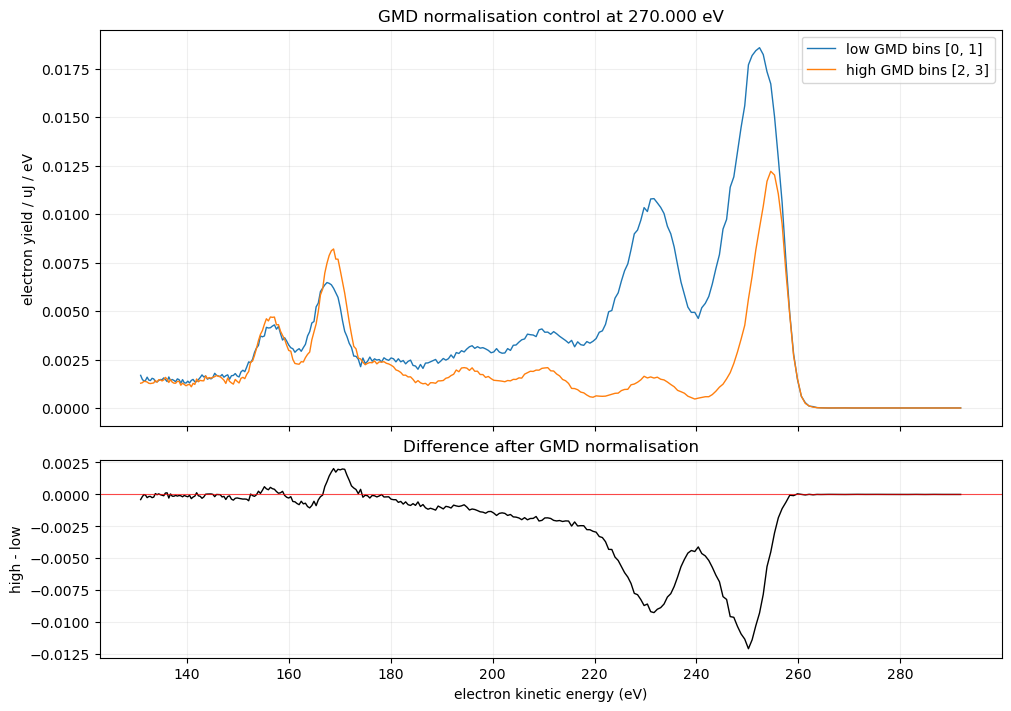

In [6]:
def smooth_1d(y, width):
    if width is None or width <= 1:
        return y
    kernel = np.ones(int(width), dtype=float) / float(width)
    return np.convolve(y, kernel, mode="same")


low = aggregate_group_spectrum(control_agg, LOW_GMD_BINS)
high = aggregate_group_spectrum(control_agg, HIGH_GMD_BINS)

delta = high["spectrum"] - low["spectrum"]

ke_low, y_low = tof_lineout_to_ke_density(control_agg.tof_edges, low["spectrum"], TOF_RANGE)
ke_high, y_high = tof_lineout_to_ke_density(control_agg.tof_edges, high["spectrum"], TOF_RANGE)
ke_delta, y_delta = tof_lineout_to_ke_density(control_agg.tof_edges, delta, TOF_RANGE)

y_low = smooth_1d(y_low, SMOOTH_BINS)
y_high = smooth_1d(y_high, SMOOTH_BINS)
y_delta = smooth_1d(y_delta, SMOOTH_BINS)

# Basic diagnostics in the displayed KE range.
common = np.isfinite(y_low) & np.isfinite(y_high)
rms_delta = np.sqrt(np.nanmean((y_high[common] - y_low[common]) ** 2)) if common.any() else np.nan
mean_signal = 0.5 * (np.nanmean(np.abs(y_high[common])) + np.nanmean(np.abs(y_low[common]))) if common.any() else np.nan
rel_rms = rms_delta / mean_signal if mean_signal > 0 else np.nan

print("Control GMD-normalisation diagnostics:")
print(f"  low shots      = {low['shots']}")
print(f"  high shots     = {high['shots']}")
print(f"  low sum GMD    = {low['sum_gmd']:.6g} uJ")
print(f"  high sum GMD   = {high['sum_gmd']:.6g} uJ")
print(f"  RMS delta      = {rms_delta:.6g} counts / uJ / eV")
print(f"  relative RMS   = {100 * rel_rms:.3g} %")

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)

axes[0].plot(
    ke_low,
    y_low,
    lw=1.0,
    label=f"low GMD bins {LOW_GMD_BINS.tolist()}",
)

axes[0].plot(
    ke_high,
    y_high,
    lw=1.0,
    label=f"high GMD bins {HIGH_GMD_BINS.tolist()}",
)

axes[0].set_ylabel("electron yield / uJ / eV")
axes[0].set_title(f"GMD normalisation control at {control_energy:.3f} eV")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(ke_delta, y_delta, lw=1.0, color="k")
axes[1].axhline(0.0, color="r", lw=0.8, alpha=0.7)
axes[1].set_xlabel("electron kinetic energy (eV)")
axes[1].set_ylabel("high - low")
axes[1].set_title("Difference after GMD normalisation")
axes[1].grid(alpha=0.2)

if KE_XLIM is not None:
    axes[1].set_xlim(KE_XLIM)

plt.show()

## Extra checks to see what is going on 

In [7]:
DIAG_ENERGY_EV = 270.0
TOF_RANGE = (800, 1100)
KE_XLIM = (160, 280)
SMOOTH_BINS = 1

energies_available = np.array([e for _, e in files], dtype=float)
i_diag = int(np.argmin(np.abs(energies_available - DIAG_ENERGY_EV)))

diag_path, diag_energy = files[i_diag]
diag_agg = load_aggregates_etof(diag_path)

print(f"Requested diagnostic energy: {DIAG_ENERGY_EV:.3f} eV")
print(f"Using file                  : {diag_path.name}")
print(f"Parsed photon energy         : {diag_energy:.3f} eV")
print(f"Aggregate mode               : {diag_agg.mode}")
print(f"D shape                      : {diag_agg.D.shape}")
print(f"GMD edges                    : {diag_agg.gmd_edges}")

Requested diagnostic energy: 270.000 eV
Using file                  : glycine_WL_scan_270.0eV_aggregates_etof1.h5
Parsed photon energy         : 270.000 eV
Aggregate mode               : spectral
D shape                      : (4, 5000)
GMD edges                    : [ 0.  3.  6. 12. 24.]


In [8]:
def ke_window_weights_from_tof_edges(tof_edges, ke_min=None, ke_max=None):
    """
    Fractional TOF-bin coverage by a KE window.

    Returns one weight per TOF bin. This is for integrals over selected
    electron kinetic-energy ranges.
    """
    tof_edges = np.asarray(tof_edges, dtype=float)
    ke_edges = tof_to_ke(tof_edges)

    e0 = ke_edges[:-1]
    e1 = ke_edges[1:]

    lo = np.minimum(e0, e1)
    hi = np.maximum(e0, e1)
    width = hi - lo

    if ke_min is None:
        ke_min = -np.inf
    if ke_max is None:
        ke_max = np.inf

    overlap = np.maximum(
        0.0,
        np.minimum(hi, ke_max) - np.maximum(lo, ke_min),
    )

    weights = np.zeros_like(width, dtype=float)
    good = np.isfinite(lo) & np.isfinite(hi) & (width > 0)
    weights[good] = overlap[good] / width[good]
    return weights


def aggregate_bin_arrays(agg):
    """
    Return per-GMD-bin additive quantities.

    For spectral aggregates:
      D: (gmd, tof)
      G: (gmd,)
      n: (gmd,)

    For time-resolved aggregates:
      D: (gmd, z, tof), summed over z
      G: (gmd, z)
      n: (gmd, z)
    """
    D = np.asarray(agg.D, dtype=float)
    G = np.asarray(agg.G, dtype=float)
    n = np.asarray(agg.n_per_bin, dtype=float)

    if D.ndim == 2:
        counts_g_tof = np.nan_to_num(D, nan=0.0) * n[:, None]
        gmd_sum_g = np.nan_to_num(G, nan=0.0) * n
        shots_g = n

    elif D.ndim == 3:
        counts_g_tof = np.nansum(np.nan_to_num(D, nan=0.0) * n[:, :, None], axis=1)
        gmd_sum_g = np.nansum(np.nan_to_num(G, nan=0.0) * n, axis=1)
        shots_g = np.nansum(n, axis=1)

    else:
        raise ValueError(f"Expected D to have 2 or 3 dimensions, got {D.shape}")

    return counts_g_tof, gmd_sum_g, shots_g


def spectrum_for_gmd_bins(agg, gmd_bins):
    counts_g_tof, gmd_sum_g, shots_g = aggregate_bin_arrays(agg)
    gmd_bins = np.asarray(gmd_bins, dtype=int)

    counts = np.nansum(counts_g_tof[gmd_bins], axis=0)
    sum_gmd = float(np.nansum(gmd_sum_g[gmd_bins]))
    shots = int(np.nansum(shots_g[gmd_bins]))

    with np.errstate(invalid="ignore", divide="ignore"):
        spec = counts / sum_gmd

    spec[~np.isfinite(spec)] = np.nan

    return {
        "spectrum": spec,
        "counts": counts,
        "sum_gmd": sum_gmd,
        "shots": shots,
    }


def smooth_1d(y, width):
    if width is None or width <= 1:
        return y
    kernel = np.ones(int(width), dtype=float) / float(width)
    return np.convolve(y, kernel, mode="same")

In [9]:
PRINT_KE_RANGE = (180, 280)

counts_g_tof, gmd_sum_g, shots_g = aggregate_bin_arrays(diag_agg)
weights_print = ke_window_weights_from_tof_edges(
    diag_agg.tof_edges,
    PRINT_KE_RANGE[0],
    PRINT_KE_RANGE[1],
)

print(f"Per-GMD-bin diagnostics at {diag_energy:.3f} eV")
print(f"Integrated electron range: KE {PRINT_KE_RANGE[0]}-{PRINT_KE_RANGE[1]} eV")
print()

rows = []

for g in range(diag_agg.n_gmd_bins):
    shots = shots_g[g]
    sum_gmd = gmd_sum_g[g]
    mean_gmd = sum_gmd / shots if shots > 0 else np.nan

    electrons = float(np.nansum(counts_g_tof[g] * weights_print))
    electrons_per_shot = electrons / shots if shots > 0 else np.nan
    electrons_per_gmd = electrons / sum_gmd if sum_gmd > 0 else np.nan

    rows.append({
        "gmd_bin": g,
        "gmd_lo": diag_agg.gmd_edges[g],
        "gmd_hi": diag_agg.gmd_edges[g + 1],
        "shots": shots,
        "mean_gmd": mean_gmd,
        "sum_gmd": sum_gmd,
        "electrons_per_shot": electrons_per_shot,
        "electrons_per_gmd": electrons_per_gmd,
    })

    print(
        f"bin {g}: "
        f"GMD [{diag_agg.gmd_edges[g]:.3g}, {diag_agg.gmd_edges[g + 1]:.3g}) uJ  "
        f"shots={int(shots):9d}  "
        f"meanGMD={mean_gmd:9.4g}  "
        f"sumGMD={sum_gmd:12.6g}  "
        f"e/shot={electrons_per_shot:12.6g}  "
        f"e/sumGMD={electrons_per_gmd:12.6g}"
    )

Per-GMD-bin diagnostics at 270.000 eV
Integrated electron range: KE 180-280 eV

bin 0: GMD [0, 3) uJ  shots=   144049  meanGMD=    1.196  sumGMD=      172344  e/shot=    0.770844  e/sumGMD=    0.644289
bin 1: GMD [3, 6) uJ  shots=    67651  meanGMD=     4.38  sumGMD=      296316  e/shot=     1.77804  e/sumGMD=    0.405939
bin 2: GMD [6, 12) uJ  shots=    69688  meanGMD=    8.518  sumGMD=      593589  e/shot=     1.82092  e/sumGMD=    0.213777
bin 3: GMD [12, 24) uJ  shots=    18940  meanGMD=    14.52  sumGMD=      274929  e/shot=     1.68045  e/sumGMD=    0.115767


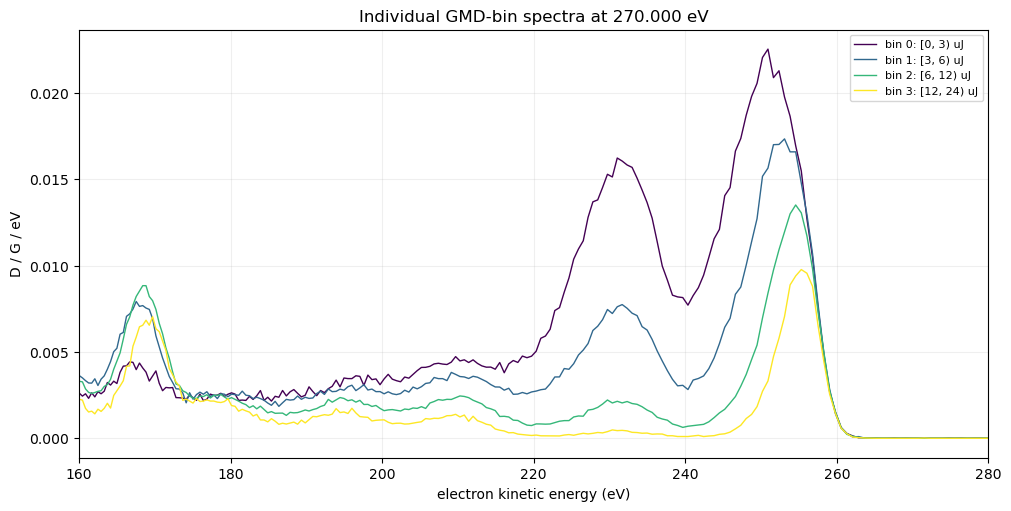

In [10]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

cmap = plt.get_cmap("viridis")
n_gmd = diag_agg.n_gmd_bins

for g in range(n_gmd):
    spec_g = spectrum_for_gmd_bins(diag_agg, [g])["spectrum"]
    ke, y = tof_lineout_to_ke_density(diag_agg.tof_edges, spec_g, TOF_RANGE)
    y = smooth_1d(y, SMOOTH_BINS)

    label = (
        f"bin {g}: "
        f"[{diag_agg.gmd_edges[g]:.2g}, {diag_agg.gmd_edges[g + 1]:.2g}) uJ"
    )

    ax.plot(
        ke,
        y,
        lw=1.0,
        color=cmap(g / max(n_gmd - 1, 1)),
        label=label,
    )

ax.set_xlabel("electron kinetic energy (eV)")
ax.set_ylabel("D / G / eV")
ax.set_title(f"Individual GMD-bin spectra at {diag_energy:.3f} eV")
ax.grid(alpha=0.2)
ax.legend(fontsize=8)

if KE_XLIM is not None:
    ax.set_xlim(KE_XLIM)

plt.show()

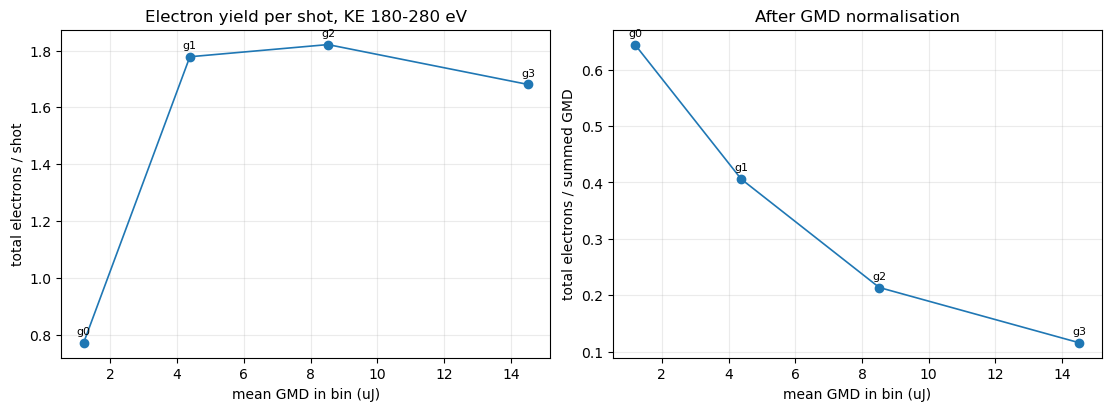

In [11]:
mean_gmd = np.array([r["mean_gmd"] for r in rows], dtype=float)
electrons_per_shot = np.array([r["electrons_per_shot"] for r in rows], dtype=float)
electrons_per_gmd = np.array([r["electrons_per_gmd"] for r in rows], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)

axes[0].plot(mean_gmd, electrons_per_shot, "o-", lw=1.2)
axes[0].set_xlabel("mean GMD in bin (uJ)")
axes[0].set_ylabel("total electrons / shot")
axes[0].set_title(f"Electron yield per shot, KE {PRINT_KE_RANGE[0]}-{PRINT_KE_RANGE[1]} eV")
axes[0].grid(alpha=0.25)

axes[1].plot(mean_gmd, electrons_per_gmd, "o-", lw=1.2)
axes[1].set_xlabel("mean GMD in bin (uJ)")
axes[1].set_ylabel("total electrons / summed GMD")
axes[1].set_title("After GMD normalisation")
axes[1].grid(alpha=0.25)

for ax in axes:
    for r in rows:
        ax.annotate(
            f"g{r['gmd_bin']}",
            (r["mean_gmd"], r["electrons_per_shot"] if ax is axes[0] else r["electrons_per_gmd"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
        )

plt.show()

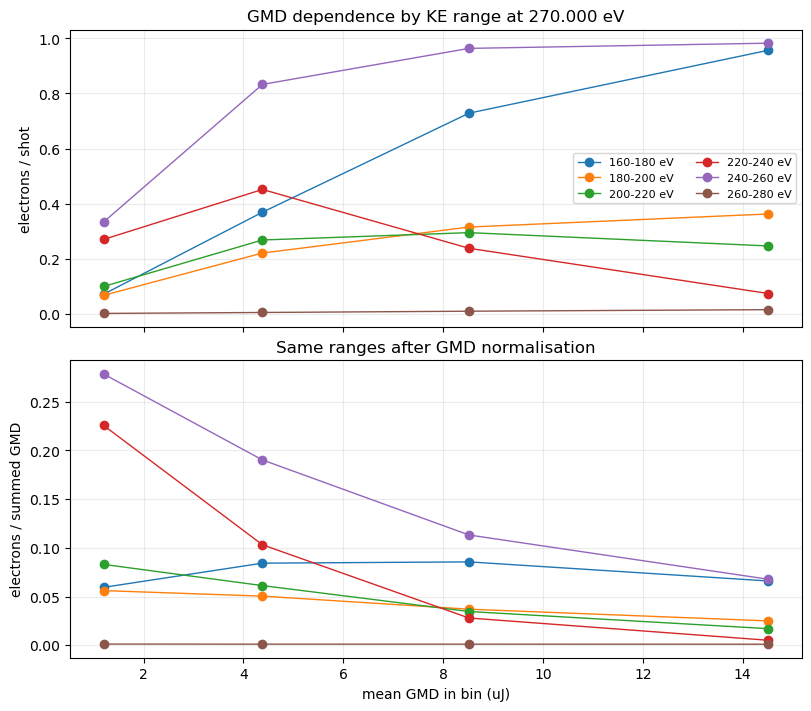

In [12]:
KE_RANGES = [
    (160, 180),
    (180, 200),
    (200, 220),
    (220, 240),
    (240, 260),
    (260, 280),
]

fig, axes = plt.subplots(
    2, 1,
    figsize=(8, 7),
    sharex=True,
    constrained_layout=True,
)

for ke_min, ke_max in KE_RANGES:
    w = ke_window_weights_from_tof_edges(diag_agg.tof_edges, ke_min, ke_max)

    y_per_shot = []
    y_per_gmd = []

    for g in range(diag_agg.n_gmd_bins):
        electrons = float(np.nansum(counts_g_tof[g] * w))
        shots = shots_g[g]
        sum_gmd = gmd_sum_g[g]

        y_per_shot.append(electrons / shots if shots > 0 else np.nan)
        y_per_gmd.append(electrons / sum_gmd if sum_gmd > 0 else np.nan)

    axes[0].plot(mean_gmd, y_per_shot, "o-", lw=1.0, label=f"{ke_min}-{ke_max} eV")
    axes[1].plot(mean_gmd, y_per_gmd, "o-", lw=1.0, label=f"{ke_min}-{ke_max} eV")

axes[0].set_ylabel("electrons / shot")
axes[0].set_title(f"GMD dependence by KE range at {diag_energy:.3f} eV")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncols=2)

axes[1].set_xlabel("mean GMD in bin (uJ)")
axes[1].set_ylabel("electrons / summed GMD")
axes[1].set_title("Same ranges after GMD normalisation")
axes[1].grid(alpha=0.25)

plt.show()

Restricted GMD comparison:
  low  (3.0, 6.0) uJ bins [1]: shots=67651, sumGMD=296316
  high (6.0, 12.0) uJ bins [2]: shots=69688, sumGMD=593589


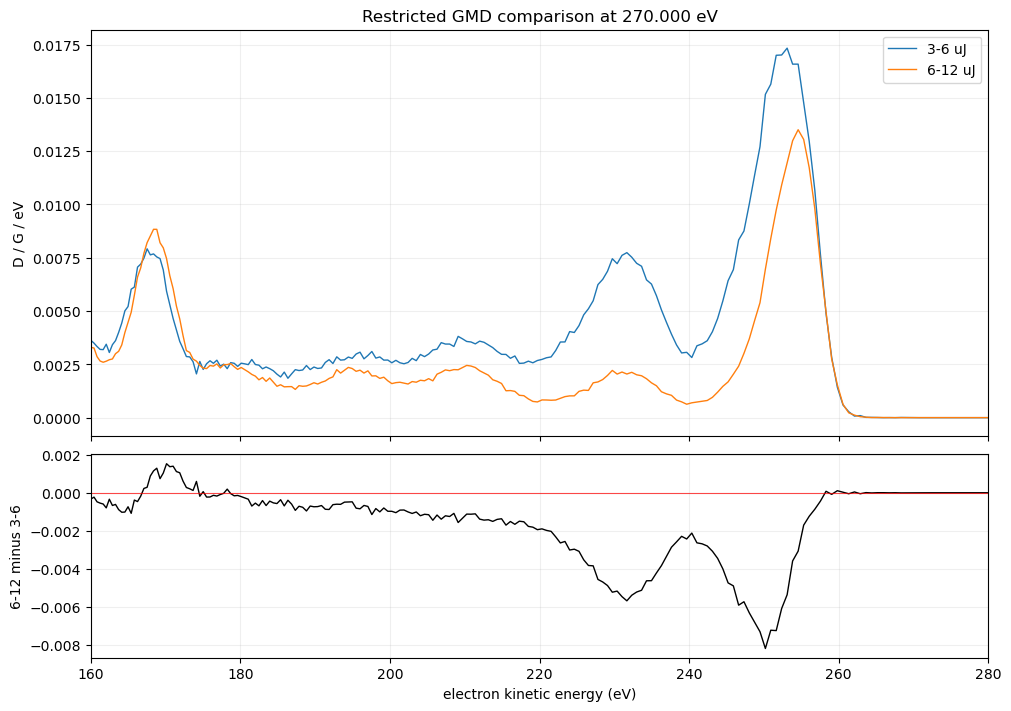

In [13]:
LOW_GMD_RANGE = (3.0, 6.0)
HIGH_GMD_RANGE = (6.0, 12.0)


def gmd_bins_matching_edges(gmd_edges, wanted_range, atol=1e-9):
    lo, hi = wanted_range
    bins = []

    for g in range(len(gmd_edges) - 1):
        if np.isclose(gmd_edges[g], lo, atol=atol) and np.isclose(gmd_edges[g + 1], hi, atol=atol):
            bins.append(g)

    if not bins:
        raise ValueError(f"No exact GMD bin found for range {wanted_range}; edges are {gmd_edges}")

    return np.array(bins, dtype=int)


low_mid_bins = gmd_bins_matching_edges(diag_agg.gmd_edges, LOW_GMD_RANGE)
high_mid_bins = gmd_bins_matching_edges(diag_agg.gmd_edges, HIGH_GMD_RANGE)

low_mid = spectrum_for_gmd_bins(diag_agg, low_mid_bins)
high_mid = spectrum_for_gmd_bins(diag_agg, high_mid_bins)
delta_mid = high_mid["spectrum"] - low_mid["spectrum"]

ke_low_mid, y_low_mid = tof_lineout_to_ke_density(diag_agg.tof_edges, low_mid["spectrum"], TOF_RANGE)
ke_high_mid, y_high_mid = tof_lineout_to_ke_density(diag_agg.tof_edges, high_mid["spectrum"], TOF_RANGE)
ke_delta_mid, y_delta_mid = tof_lineout_to_ke_density(diag_agg.tof_edges, delta_mid, TOF_RANGE)

y_low_mid = smooth_1d(y_low_mid, SMOOTH_BINS)
y_high_mid = smooth_1d(y_high_mid, SMOOTH_BINS)
y_delta_mid = smooth_1d(y_delta_mid, SMOOTH_BINS)

print("Restricted GMD comparison:")
print(f"  low  {LOW_GMD_RANGE} uJ bins {low_mid_bins.tolist()}: shots={low_mid['shots']}, sumGMD={low_mid['sum_gmd']:.6g}")
print(f"  high {HIGH_GMD_RANGE} uJ bins {high_mid_bins.tolist()}: shots={high_mid['shots']}, sumGMD={high_mid['sum_gmd']:.6g}")

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2.0, 1.0]},
)

axes[0].plot(ke_low_mid, y_low_mid, lw=1.0, label="3-6 uJ")
axes[0].plot(ke_high_mid, y_high_mid, lw=1.0, label="6-12 uJ")
axes[0].set_ylabel("D / G / eV")
axes[0].set_title(f"Restricted GMD comparison at {diag_energy:.3f} eV")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(ke_delta_mid, y_delta_mid, lw=1.0, color="k")
axes[1].axhline(0.0, color="r", lw=0.8, alpha=0.7)
axes[1].set_xlabel("electron kinetic energy (eV)")
axes[1].set_ylabel("6-12 minus 3-6")
axes[1].grid(alpha=0.2)

if KE_XLIM is not None:
    axes[1].set_xlim(KE_XLIM)

plt.show()

### Further checks

In [14]:
print("Aggregate-generation definitions from analysis/scripts/compute_aggregates.py")
print()
print("For each kept shot i in a GMD bin b:")
print("  G_i = scalar GMD value for that shot")
print("  D_i(E) = histogram of nonzero tofs_e hits for that shot on tof_edges")
print()
print("Accumulated per aggregate bin b:")
print("  n_per_bin[b] = N_b")
print("               = number of valid shots assigned to bin b")
print()
print("  G_sum[b] = sum_i G_i")
print("  D_sum[b, E] = sum_i D_i(E)")
print()
print("Saved quantities are MEANS:")
print("  G[b] = G_sum[b] / n_per_bin[b]")
print("  D[b, E] = D_sum[b, E] / n_per_bin[b]")
print()
print("Therefore the correct GMD-normalised yield is:")
print("  S_b(E) = D_sum[b, E] / G_sum[b]")
print("         = D[b, E] * n_per_bin[b] / (G[b] * n_per_bin[b])")
print("         = D[b, E] / G[b] for a single aggregate bin")
print()
print("For several bins grouped together:")
print("  S_group(E) = sum_b D[b, E] * n_per_bin[b] / sum_b G[b] * n_per_bin[b]")
print()
print("GMD bin assignment:")
print("  gmd_bin = np.digitize(G_i, gmd_edges) - 1")
print("  shots outside [gmd_edges[0], gmd_edges[-1]) or with NaN GMD are dropped")
print()
print("Important upstream note:")
print("  compute_aggregates does not create eTOF peaks.")
print("  It only histograms the nonzero entries already stored in the source /tofs_e dataset.")
print("  So any hit-count cap must be checked in the source combined .h5 shape and upstream write_h5/peak finding.")

Aggregate-generation definitions from analysis/scripts/compute_aggregates.py

For each kept shot i in a GMD bin b:
  G_i = scalar GMD value for that shot
  D_i(E) = histogram of nonzero tofs_e hits for that shot on tof_edges

Accumulated per aggregate bin b:
  n_per_bin[b] = N_b
               = number of valid shots assigned to bin b

  G_sum[b] = sum_i G_i
  D_sum[b, E] = sum_i D_i(E)

Saved quantities are MEANS:
  G[b] = G_sum[b] / n_per_bin[b]
  D[b, E] = D_sum[b, E] / n_per_bin[b]

Therefore the correct GMD-normalised yield is:
  S_b(E) = D_sum[b, E] / G_sum[b]
         = D[b, E] * n_per_bin[b] / (G[b] * n_per_bin[b])
         = D[b, E] / G[b] for a single aggregate bin

For several bins grouped together:
  S_group(E) = sum_b D[b, E] * n_per_bin[b] / sum_b G[b] * n_per_bin[b]

GMD bin assignment:
  gmd_bin = np.digitize(G_i, gmd_edges) - 1
  shots outside [gmd_edges[0], gmd_edges[-1]) or with NaN GMD are dropped

Important upstream note:
  compute_aggregates does not create eTOF p

In [15]:
source_h5 = Path(diag_agg.metadata.get("input_h5", ""))

print("Aggregate file:", diag_path)
print("Source H5     :", source_h5)
print("Exists        :", source_h5.exists())

if not source_h5.exists():
    raise FileNotFoundError(
        f"Source H5 from aggregate metadata does not exist here:\n{source_h5}"
    )

with h5py.File(source_h5, "r") as f:
    print("Top-level datasets/groups:")
    for k in f.keys():
        obj = f[k]
        shape = getattr(obj, "shape", "")
        dtype = getattr(obj, "dtype", "")
        print(f"  {k:24s} shape={str(shape):20s} dtype={dtype}")

    print()
    print("Source attributes:")
    for k, v in f.attrs.items():
        print(f"  {k}: {v}")

    if "tofs_e" not in f:
        raise KeyError("Source H5 has no /tofs_e dataset")

    print()
    print("eTOF hit-slot check:")
    print("  tofs_e shape:", f["tofs_e"].shape)
    print("  max eTOF hit slots per shot:", f["tofs_e"].shape[-1])

    if "tofs_i" in f:
        print("  tofs_i shape:", f["tofs_i"].shape)
        print("  max iTOF hit slots per shot:", f["tofs_i"].shape[-1])

Aggregate file: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/glycine_WL_scan_270.0eV_aggregates_etof1.h5
Source H5     : /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/glycine_WL_scan_270.0eV.h5
Exists        : True
Top-level datasets/groups:
  between_tdc_files        shape=(3003,)              dtype=bool
  gmd                      shape=(3003, 101)          dtype=float32
  hor_pos                  shape=(3003,)              dtype=float32
  local_DAQ_running        shape=(3003,)              dtype=bool
  mpe                      shape=(3003,)              dtype=float32
  tID                      shape=(3003,)              dtype=float64
  tofs_e                   shape=(3003, 101, 50)      dtype=uint32
  tofs_i                   shape=(3003, 101, 120)     dtype=uint32
  ver_pos                  shape=(3003,)              dtype=float32
  z                        shape=(3003, 101)          dtype=float32
  z_std                    shape=(3003, 101)          d

In [16]:
# Use the aggregate metadata trim so this matches compute_aggregates as closely as possible.
TRIM_START = int(diag_agg.metadata.get("trim_start", 0))
TRIM_END = int(diag_agg.metadata.get("trim_end", 0))

# For counting all detected electrons, use TOF_COUNT_RANGE = None.
# For the eTOF region you have been plotting, use something like (800, 1100).
TOF_COUNT_RANGE = None

# Finer GMD binning for the shot-resolved check.
FINE_GMD_BIN_WIDTH = 0.25  # uJ
GMD_MAX_FOR_FINE = None    # None = use 99.9 percentile from data

CHUNK_TRAINS = 1000


def keep_mask_like_compute_aggregates(f, trim_start=0, trim_end=0):
    if "between_tdc_files" not in f:
        keep = np.ones(f["gmd"].shape[0], dtype=bool)
    else:
        btf = f["between_tdc_files"][:].astype(bool)
        good_pos = np.where(~btf)[0]

        if trim_end > 0:
            good_pos = good_pos[trim_start:-trim_end]
        else:
            good_pos = good_pos[trim_start:]

        keep = np.zeros(btf.shape[0], dtype=bool)
        keep[good_pos] = True

    return keep


def count_hits_in_range(tofs, tof_range=None):
    mask = tofs > 0
    if tof_range is not None:
        lo, hi = tof_range
        if lo is not None:
            mask &= tofs >= lo
        if hi is not None:
            mask &= tofs < hi
    return np.count_nonzero(mask, axis=-1).astype(np.float64)


def read_shot_gmd_and_counts(source_h5, tof_range=None, chunk_trains=1000):
    gmd_all = []
    counts_all = []
    saturated_all = []

    with h5py.File(source_h5, "r") as f:
        keep = keep_mask_like_compute_aggregates(f, TRIM_START, TRIM_END)
        n_trains = f["gmd"].shape[0]
        max_slots = f["tofs_e"].shape[-1]

        for s in range(0, n_trains, chunk_trains):
            e = min(s + chunk_trains, n_trains)
            row_keep = keep[s:e]
            if not row_keep.any():
                continue

            gmd = f["gmd"][s:e][row_keep]
            tofs = f["tofs_e"][s:e][row_keep]

            counts = count_hits_in_range(tofs, tof_range=tof_range)
            saturated = count_hits_in_range(tofs, tof_range=None) >= max_slots

            gmd_flat = gmd.ravel()
            counts_flat = counts.ravel()
            saturated_flat = saturated.ravel()

            ok = np.isfinite(gmd_flat)
            gmd_all.append(gmd_flat[ok])
            counts_all.append(counts_flat[ok])
            saturated_all.append(saturated_flat[ok])

    return (
        np.concatenate(gmd_all),
        np.concatenate(counts_all),
        np.concatenate(saturated_all),
        max_slots,
    )


gmd_shot, ecount_shot, saturated_shot, max_slots = read_shot_gmd_and_counts(
    source_h5,
    tof_range=TOF_COUNT_RANGE,
    chunk_trains=CHUNK_TRAINS,
)

print("Shot-resolved arrays:")
print("  shots read:", gmd_shot.size)
print("  GMD range :", np.nanmin(gmd_shot), "to", np.nanmax(gmd_shot))
print("  count range:", np.nanmin(ecount_shot), "to", np.nanmax(ecount_shot))
print("  max stored eTOF slots:", max_slots)
print("  fraction of shots with all eTOF slots filled:", np.mean(saturated_shot))

Shot-resolved arrays:
  shots read: 300677
  GMD range : -0.101365104 to 27.165844
  count range: 0.0 to 50.0
  max stored eTOF slots: 50
  fraction of shots with all eTOF slots filled: 6.65165609607652e-06


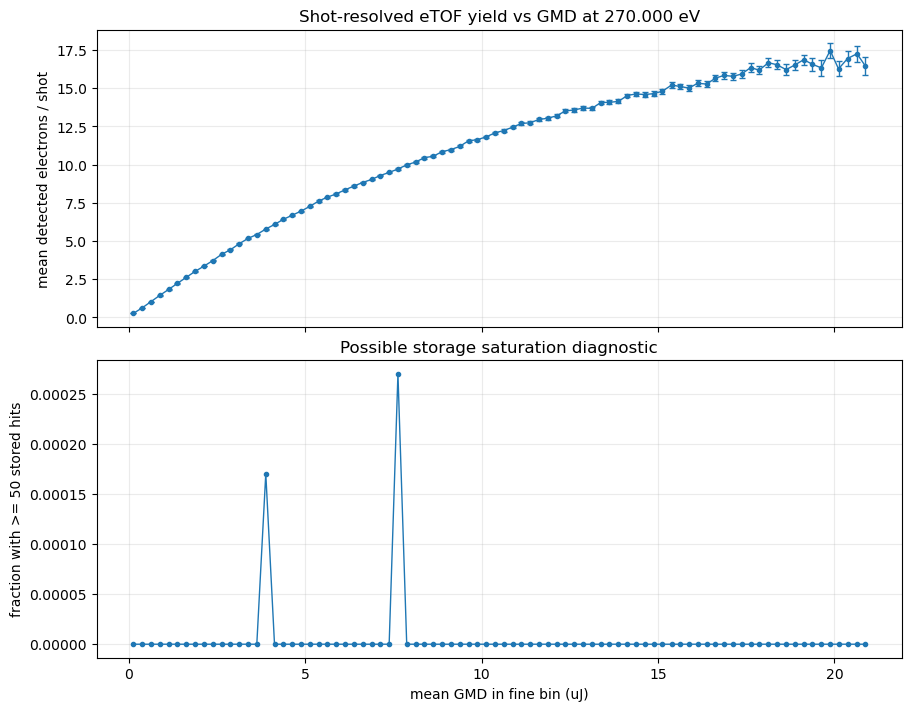

Fine-bin summary:
  GMD=  0.1257 uJ  N=   21348  e/shot=   0.26874  slot-filled frac=        0
  GMD=  0.3737 uJ  N=   18856  e/shot=   0.63099  slot-filled frac=        0
  GMD=  0.6197 uJ  N=   17040  e/shot=    1.0305  slot-filled frac=        0
  GMD=  0.8693 uJ  N=   12973  e/shot=    1.4417  slot-filled frac=        0
  GMD=  1.1256 uJ  N=   11176  e/shot=    1.8388  slot-filled frac=        0
  GMD=  1.3730 uJ  N=   12124  e/shot=    2.2333  slot-filled frac=        0
  GMD=  1.6227 uJ  N=    9940  e/shot=    2.6258  slot-filled frac=        0
  GMD=  1.8750 uJ  N=    9150  e/shot=    3.0165  slot-filled frac=        0
  GMD=  2.1238 uJ  N=    8475  e/shot=    3.3569  slot-filled frac=        0
  GMD=  2.3736 uJ  N=    7783  e/shot=    3.7177  slot-filled frac=        0
  GMD=  2.6239 uJ  N=    7433  e/shot=    4.1296  slot-filled frac=        0
  GMD=  2.8755 uJ  N=    7751  e/shot=    4.4294  slot-filled frac=        0
  GMD=  3.1241 uJ  N=    7235  e/shot=    4.8232  slot-fil

In [49]:
if GMD_MAX_FOR_FINE is None:
    gmd_hi = float(np.nanpercentile(gmd_shot, 99.9))
else:
    gmd_hi = float(GMD_MAX_FOR_FINE)

gmd_lo = 0.0
fine_edges = np.arange(gmd_lo, gmd_hi + FINE_GMD_BIN_WIDTH, FINE_GMD_BIN_WIDTH)
fine_cent = 0.5 * (fine_edges[:-1] + fine_edges[1:])

bin_id = np.digitize(gmd_shot, fine_edges) - 1
valid = (bin_id >= 0) & (bin_id < len(fine_cent)) & np.isfinite(ecount_shot)

mean_counts = np.full(len(fine_cent), np.nan)
std_counts = np.full(len(fine_cent), np.nan)
n_counts = np.zeros(len(fine_cent), dtype=int)
mean_gmd_fine = np.full(len(fine_cent), np.nan)
sat_frac = np.full(len(fine_cent), np.nan)

for b in range(len(fine_cent)):
    sel = valid & (bin_id == b)
    n_counts[b] = int(np.count_nonzero(sel))
    if n_counts[b] == 0:
        continue
    mean_counts[b] = np.nanmean(ecount_shot[sel])
    std_counts[b] = np.nanstd(ecount_shot[sel])
    mean_gmd_fine[b] = np.nanmean(gmd_shot[sel])
    sat_frac[b] = np.mean(saturated_shot[sel])

good = n_counts > 0
sem_counts = std_counts / np.sqrt(np.maximum(n_counts, 1))

fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)

axes[0].errorbar(
    mean_gmd_fine[good],
    mean_counts[good],
    yerr=sem_counts[good],
    fmt="o-",
    ms=3,
    lw=1.0,
    capsize=2,
)
axes[0].set_ylabel("mean detected electrons / shot")
axes[0].set_title(f"Shot-resolved eTOF yield vs GMD at {diag_energy:.3f} eV")
axes[0].grid(alpha=0.25)

axes[1].plot(mean_gmd_fine[good], sat_frac[good], "o-", ms=3, lw=1.0)
axes[1].set_xlabel("mean GMD in fine bin (uJ)")
axes[1].set_ylabel(f"fraction with >= {max_slots} stored hits")
axes[1].set_title("Possible storage saturation diagnostic")
axes[1].grid(alpha=0.25)

plt.show()

print("Fine-bin summary:")
for x, y, n, sf in zip(mean_gmd_fine[good], mean_counts[good], n_counts[good], sat_frac[good]):
    print(f"  GMD={x:8.4f} uJ  N={n:8d}  e/shot={y:10.5g}  slot-filled frac={sf:9.4g}")

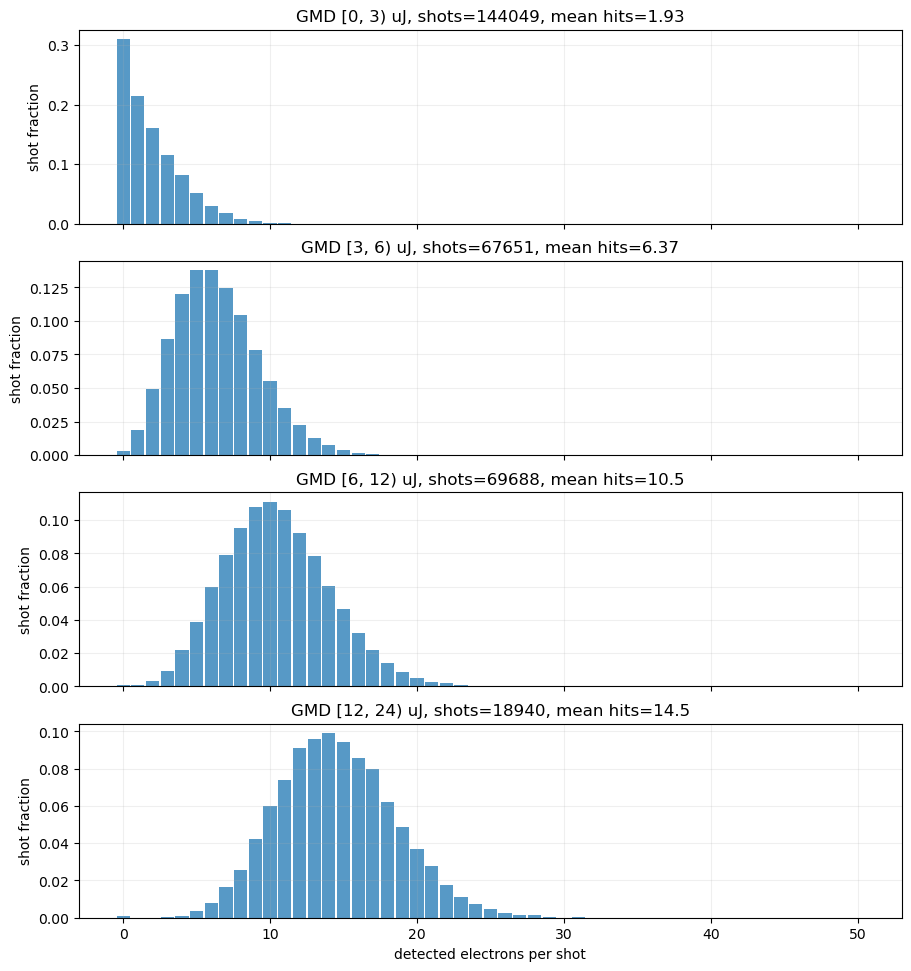

Count-distribution table:

GMD [0, 3) uJ, shots=144049
   0 hits:   0.31054
   1 hits:   0.21384
   2 hits:   0.16039
   3 hits:   0.11609
   4 hits:   0.08194
   5 hits:   0.05201
   6 hits:   0.03073
   7 hits:   0.01778
   8 hits:   0.00865
   9 hits:   0.00437
  10 hits:   0.00210
  11 hits:   0.00085
  12 hits:   0.00049
  >12 hits:   0.00023
  max observed hits: 21
  fraction at storage limit 50: 0

GMD [3, 6) uJ, shots=67651
   0 hits:   0.00334
   1 hits:   0.01845
   2 hits:   0.04899
   3 hits:   0.08683
   4 hits:   0.11995
   5 hits:   0.13768
   6 hits:   0.13780
   7 hits:   0.12442
   8 hits:   0.10421
   9 hits:   0.07830
  10 hits:   0.05524
  11 hits:   0.03534
  12 hits:   0.02213
  >12 hits:   0.02733
  max observed hits: 50
  fraction at storage limit 50: 1.47817e-05

GMD [6, 12) uJ, shots=69688
   0 hits:   0.00070
   1 hits:   0.00066
   2 hits:   0.00316
   3 hits:   0.00956
   4 hits:   0.02173
   5 hits:   0.03859
   6 hits:   0.05991
   7 hits:   0.07927
   8

In [18]:
GMD_RANGES_FOR_HIST = [
    (0.0, 3.0),
    (3.0, 6.0),
    (6.0, 12.0),
    (12.0, 24.0),
]

MAX_COUNT_TO_SHOW = min(max_slots, int(np.nanmax(ecount_shot)))
COUNT_BINS = np.arange(-0.5, MAX_COUNT_TO_SHOW + 1.5, 1.0)

fig, axes = plt.subplots(
    len(GMD_RANGES_FOR_HIST),
    1,
    figsize=(9, 2.4 * len(GMD_RANGES_FOR_HIST)),
    sharex=True,
    constrained_layout=True,
)
axes = np.atleast_1d(axes)

for ax, (lo, hi) in zip(axes, GMD_RANGES_FOR_HIST):
    sel = (
        np.isfinite(gmd_shot)
        & (gmd_shot >= lo)
        & (gmd_shot < hi)
        & np.isfinite(ecount_shot)
    )

    counts = ecount_shot[sel].astype(int)
    hist, edges = np.histogram(counts, bins=COUNT_BINS)
    frac = hist / hist.sum() if hist.sum() > 0 else hist * np.nan
    centres = 0.5 * (edges[:-1] + edges[1:])

    ax.bar(centres, frac, width=0.9, alpha=0.75)
    ax.set_ylabel("shot fraction")
    ax.set_title(
        f"GMD [{lo:g}, {hi:g}) uJ, shots={sel.sum()}, "
        f"mean hits={np.nanmean(counts) if counts.size else np.nan:.3g}"
    )
    ax.grid(alpha=0.2)

axes[-1].set_xlabel("detected electrons per shot")

plt.show()

print("Count-distribution table:")
for lo, hi in GMD_RANGES_FOR_HIST:
    sel = (
        np.isfinite(gmd_shot)
        & (gmd_shot >= lo)
        & (gmd_shot < hi)
        & np.isfinite(ecount_shot)
    )
    counts = ecount_shot[sel].astype(int)
    print()
    print(f"GMD [{lo:g}, {hi:g}) uJ, shots={counts.size}")
    if counts.size == 0:
        continue

    for k in range(0, min(MAX_COUNT_TO_SHOW, 12) + 1):
        print(f"  {k:2d} hits: {np.mean(counts == k):9.5f}")

    if MAX_COUNT_TO_SHOW > 12:
        print(f"  >12 hits: {np.mean(counts > 12):9.5f}")

    print(f"  max observed hits: {counts.max()}")
    print(f"  fraction at storage limit {max_slots}: {np.mean(counts >= max_slots):.6g}")

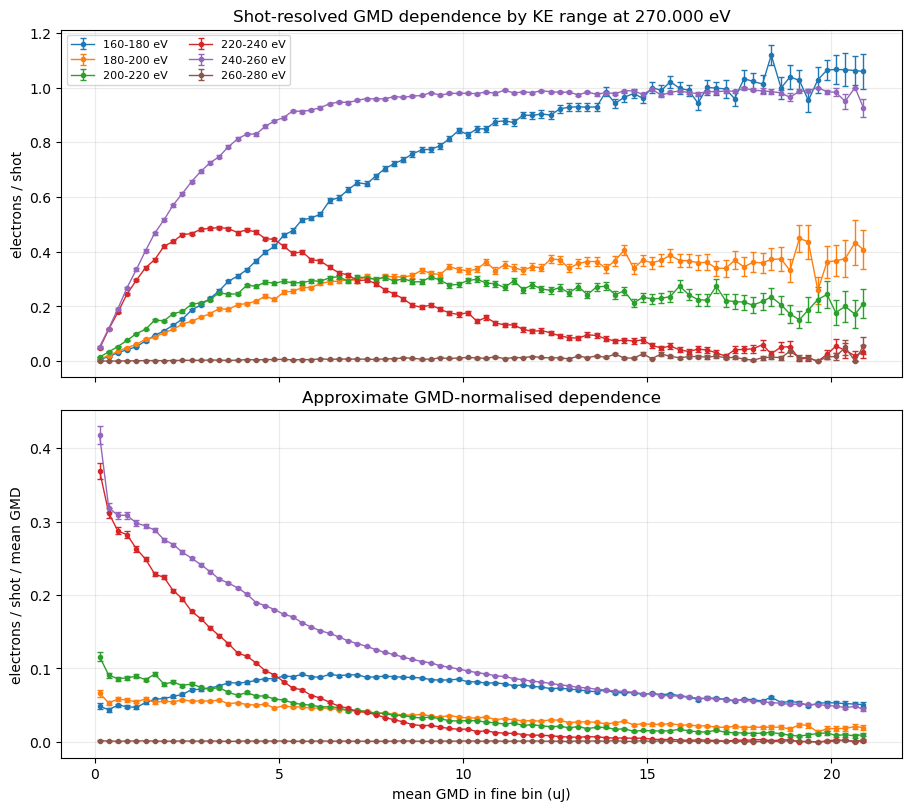

In [19]:
KE_RANGES_FINE = [
    (160, 180),
    (180, 200),
    (200, 220),
    (220, 240),
    (240, 260),
    (260, 280),
]

def read_counts_for_ke_ranges(source_h5, ke_ranges, chunk_trains=1000):
    out_counts = {tuple(r): [] for r in ke_ranges}
    gmd_all = []

    weights_by_range = {
        tuple(r): ke_window_weights_from_tof_edges(diag_agg.tof_edges, r[0], r[1])
        for r in ke_ranges
    }

    with h5py.File(source_h5, "r") as f:
        keep = keep_mask_like_compute_aggregates(f, TRIM_START, TRIM_END)
        n_trains = f["gmd"].shape[0]
        tof_edges = np.asarray(diag_agg.tof_edges, dtype=float)

        for s in range(0, n_trains, chunk_trains):
            e = min(s + chunk_trains, n_trains)
            row_keep = keep[s:e]
            if not row_keep.any():
                continue

            gmd = f["gmd"][s:e][row_keep]
            tofs = f["tofs_e"][s:e][row_keep]

            gmd_flat = gmd.ravel()
            ok = np.isfinite(gmd_flat)
            gmd_all.append(gmd_flat[ok])

            # Histogram each shot onto the aggregate TOF grid.
            n_keep, m, max_hits_this = tofs.shape
            tofs_flat = tofs.reshape(-1, max_hits_this)
            shot_ids = np.repeat(np.arange(tofs_flat.shape[0]), max_hits_this)
            tof_vals = tofs_flat.ravel()

            valid_hit = tof_vals > 0
            shot_ids = shot_ids[valid_hit]
            tof_vals = tof_vals[valid_hit]

            H, _, _ = np.histogram2d(
                shot_ids,
                tof_vals,
                bins=[np.arange(tofs_flat.shape[0] + 1) - 0.5, tof_edges],
            )

            for r in ke_ranges:
                rr = tuple(r)
                c = H @ weights_by_range[rr]
                out_counts[rr].append(c[ok])

    gmd_out = np.concatenate(gmd_all)
    counts_out = {r: np.concatenate(v) for r, v in out_counts.items()}
    return gmd_out, counts_out


gmd_ke, counts_by_ke = read_counts_for_ke_ranges(
    source_h5,
    KE_RANGES_FINE,
    chunk_trains=CHUNK_TRAINS,
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(9, 8),
    sharex=True,
    constrained_layout=True,
)

for ke_range, counts in counts_by_ke.items():
    bin_id = np.digitize(gmd_ke, fine_edges) - 1
    valid = (
        np.isfinite(gmd_ke)
        & np.isfinite(counts)
        & (bin_id >= 0)
        & (bin_id < len(fine_cent))
    )

    y_mean = np.full(len(fine_cent), np.nan)
    y_sem = np.full(len(fine_cent), np.nan)
    x_mean = np.full(len(fine_cent), np.nan)
    n_bin = np.zeros(len(fine_cent), dtype=int)

    for b in range(len(fine_cent)):
        sel = valid & (bin_id == b)
        n_bin[b] = int(np.count_nonzero(sel))
        if n_bin[b] == 0:
            continue
        y_mean[b] = np.nanmean(counts[sel])
        y_sem[b] = np.nanstd(counts[sel]) / np.sqrt(n_bin[b])
        x_mean[b] = np.nanmean(gmd_ke[sel])

    good = n_bin > 0
    label = f"{ke_range[0]}-{ke_range[1]} eV"

    axes[0].errorbar(
        x_mean[good],
        y_mean[good],
        yerr=y_sem[good],
        fmt="o-",
        ms=3,
        lw=1.0,
        capsize=2,
        label=label,
    )

    with np.errstate(invalid="ignore", divide="ignore"):
        y_over_gmd = y_mean / x_mean
        y_over_gmd_sem = y_sem / x_mean

    axes[1].errorbar(
        x_mean[good],
        y_over_gmd[good],
        yerr=y_over_gmd_sem[good],
        fmt="o-",
        ms=3,
        lw=1.0,
        capsize=2,
        label=label,
    )

axes[0].set_ylabel("electrons / shot")
axes[0].set_title(f"Shot-resolved GMD dependence by KE range at {diag_energy:.3f} eV")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncols=2)

axes[1].set_xlabel("mean GMD in fine bin (uJ)")
axes[1].set_ylabel("electrons / shot / mean GMD")
axes[1].set_title("Approximate GMD-normalised dependence")
axes[1].grid(alpha=0.25)

plt.show()

### Check low GMD values

Shot-resolved fine low-GMD control
Source H5: /asap3/flash/gpfs/fl24/2026/data/11022188/processed/combined/glycine_WL_scan_270.0eV.h5

 low GMD (0.75, 1.5): shots=    36273  meanGMD=   1.117 uJ  sumGMD=     40503.8 uJ  hits=     66330  hits/shot=    1.8286  hits/sumGMD=    1.6376
high GMD (1.5, 2.5): shots=    35348  meanGMD=   1.973 uJ  sumGMD=     69758.3 uJ  hits=    111086  hits/shot=    3.1426  hits/sumGMD=    1.5924


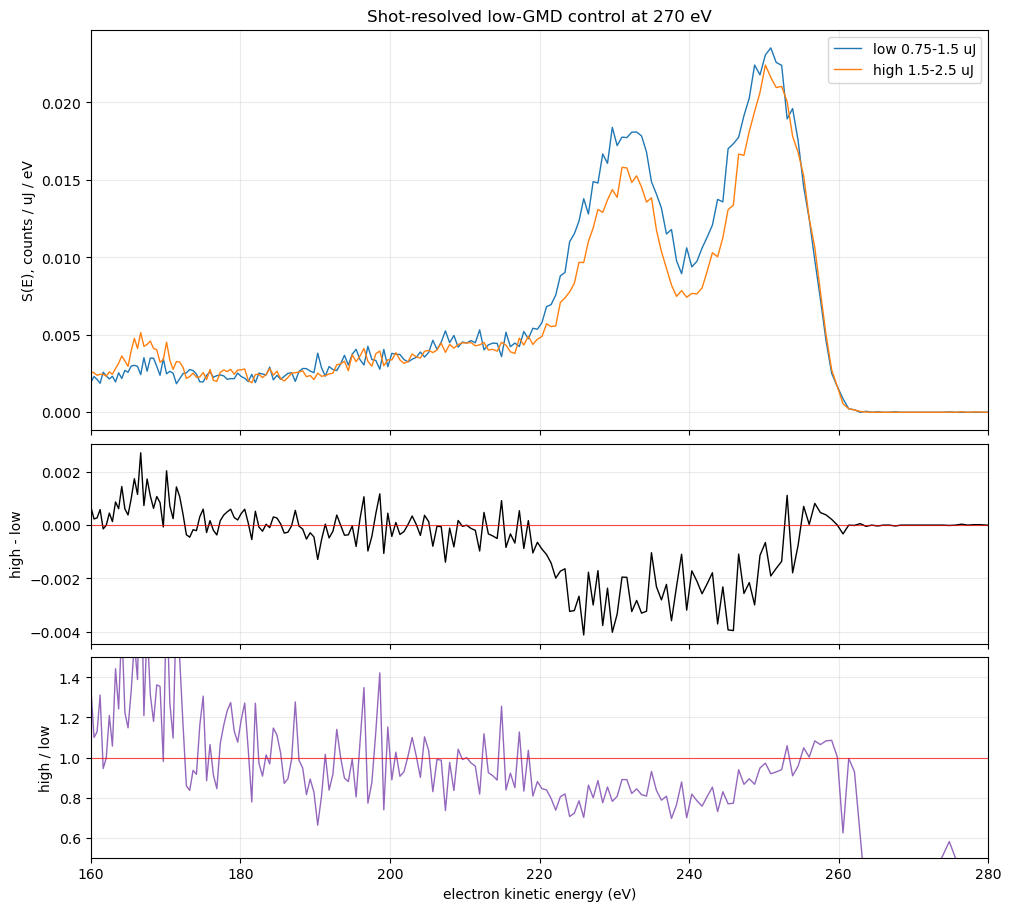

In [20]:
# --- Fine low-GMD control from shot-resolved 270 eV H5 ----------------
# Compare 0.75-1.5 uJ against 1.5-2.5 uJ using shot-by-shot GMD and tofs_e.

SOURCE_H5_270 = source_h5   # or set manually: Path("/path/to/glycine_WL_scan_270.0eV.h5")

LOW_GMD_RANGE = (0.75, 1.5)
HIGH_GMD_RANGE = (1.5, 2.5)

TOF_RANGE = (800, 1100)
KE_XLIM = (160, 280)
RATIO_YLIM = (0.5, 1.5)

CHUNK_TRAINS = 1000

# Use aggregate TOF edges if already available, otherwise use the standard 1-unit grid.
if "diag_agg" in globals() and diag_agg.tof_edges is not None:
    ETOF_EDGES_FOR_FINE_CONTROL = np.asarray(diag_agg.tof_edges, dtype=float)
else:
    ETOF_EDGES_FOR_FINE_CONTROL = np.arange(0.0, 5000.0 + 1.0, 1.0)


def keep_mask_like_compute_aggregates_from_h5(f, trim_start=0, trim_end=0):
    if "between_tdc_files" not in f:
        return np.ones(f["gmd"].shape[0], dtype=bool)

    btf = f["between_tdc_files"][:].astype(bool)
    good_pos = np.where(~btf)[0]

    if trim_end > 0:
        good_pos = good_pos[trim_start:-trim_end]
    else:
        good_pos = good_pos[trim_start:]

    keep = np.zeros(btf.shape[0], dtype=bool)
    keep[good_pos] = True
    return keep


def shot_resolved_gmd_group_spectrum(
    source_h5,
    gmd_range,
    tof_edges,
    *,
    trim_start=0,
    trim_end=0,
    chunk_trains=1000,
):
    source_h5 = Path(source_h5)
    gmd_lo, gmd_hi = gmd_range

    total_counts = np.zeros(len(tof_edges) - 1, dtype=np.float64)
    total_gmd = 0.0
    total_shots = 0
    total_hits = 0

    with h5py.File(source_h5, "r") as f:
        keep = keep_mask_like_compute_aggregates_from_h5(
            f,
            trim_start=trim_start,
            trim_end=trim_end,
        )

        n_trains = f["gmd"].shape[0]

        for s in range(0, n_trains, chunk_trains):
            e = min(s + chunk_trains, n_trains)
            row_keep = keep[s:e]
            if not row_keep.any():
                continue

            gmd = f["gmd"][s:e][row_keep]        # (n_keep, bunch)
            tofs = f["tofs_e"][s:e][row_keep]    # (n_keep, bunch, max_hits)

            gmd_flat = gmd.ravel()
            tofs_flat = tofs.reshape(-1, tofs.shape[-1])

            shot_sel = (
                np.isfinite(gmd_flat)
                & (gmd_flat >= gmd_lo)
                & (gmd_flat < gmd_hi)
            )

            if not shot_sel.any():
                continue

            hits = tofs_flat[shot_sel].ravel()
            hits = hits[hits > 0]

            hist, _ = np.histogram(hits, bins=tof_edges)

            total_counts += hist.astype(np.float64)
            total_gmd += float(np.nansum(gmd_flat[shot_sel]))
            total_shots += int(np.count_nonzero(shot_sel))
            total_hits += int(hits.size)

    with np.errstate(invalid="ignore", divide="ignore"):
        spectrum = total_counts / total_gmd

    spectrum[~np.isfinite(spectrum)] = np.nan

    return {
        "spectrum": spectrum,
        "counts": total_counts,
        "sum_gmd": total_gmd,
        "shots": total_shots,
        "hits": total_hits,
        "gmd_range": gmd_range,
    }


def tof_spectrum_to_ke_density(tof_edges, y, tof_range):
    tof_edges = np.asarray(tof_edges, dtype=float)
    y = np.asarray(y, dtype=float)

    tof_cent = 0.5 * (tof_edges[:-1] + tof_edges[1:])
    mask = np.ones_like(tof_cent, dtype=bool)

    if tof_range[0] is not None:
        mask &= tof_cent >= tof_range[0]
    if tof_range[1] is not None:
        mask &= tof_cent <= tof_range[1]

    idx = np.where(mask)[0]
    if idx.size == 0:
        raise ValueError(f"No TOF bins inside TOF_RANGE={tof_range}")

    lo = int(idx[0])
    hi = int(idx[-1]) + 1

    ke_edges = tof_to_ke(tof_edges[lo:hi + 1])
    ke_cent = tof_to_ke(tof_cent[lo:hi])
    y_s = y[lo:hi].astype(float)

    if not np.all(np.isfinite(ke_edges)):
        raise ValueError("Some KE edges are NaN. Choose TOF_RANGE fully above t0.")

    dke = np.abs(np.diff(ke_edges))
    with np.errstate(invalid="ignore", divide="ignore"):
        y_s = y_s / dke

    good = np.isfinite(ke_cent) & np.isfinite(y_s)
    order = np.argsort(ke_cent[good])

    return ke_cent[good][order], y_s[good][order]


TRIM_START_FINE = int(diag_agg.metadata.get("trim_start", 0)) if "diag_agg" in globals() else 0
TRIM_END_FINE = int(diag_agg.metadata.get("trim_end", 0)) if "diag_agg" in globals() else 0

low_fine = shot_resolved_gmd_group_spectrum(
    SOURCE_H5_270,
    LOW_GMD_RANGE,
    ETOF_EDGES_FOR_FINE_CONTROL,
    trim_start=TRIM_START_FINE,
    trim_end=TRIM_END_FINE,
    chunk_trains=CHUNK_TRAINS,
)

high_fine = shot_resolved_gmd_group_spectrum(
    SOURCE_H5_270,
    HIGH_GMD_RANGE,
    ETOF_EDGES_FOR_FINE_CONTROL,
    trim_start=TRIM_START_FINE,
    trim_end=TRIM_END_FINE,
    chunk_trains=CHUNK_TRAINS,
)

diff_fine = high_fine["spectrum"] - low_fine["spectrum"]

with np.errstate(invalid="ignore", divide="ignore"):
    ratio_fine = high_fine["spectrum"] / low_fine["spectrum"]

ke_low, y_low = tof_spectrum_to_ke_density(
    ETOF_EDGES_FOR_FINE_CONTROL,
    low_fine["spectrum"],
    TOF_RANGE,
)
ke_high, y_high = tof_spectrum_to_ke_density(
    ETOF_EDGES_FOR_FINE_CONTROL,
    high_fine["spectrum"],
    TOF_RANGE,
)
ke_diff, y_diff = tof_spectrum_to_ke_density(
    ETOF_EDGES_FOR_FINE_CONTROL,
    diff_fine,
    TOF_RANGE,
)

# Ratio is dimensionless, so do not divide by dKE. Use TOF centres converted to KE.
tof_cent = 0.5 * (ETOF_EDGES_FOR_FINE_CONTROL[:-1] + ETOF_EDGES_FOR_FINE_CONTROL[1:])
tof_mask = (tof_cent >= TOF_RANGE[0]) & (tof_cent <= TOF_RANGE[1])
ke_ratio = tof_to_ke(tof_cent[tof_mask])
ratio_plot = ratio_fine[tof_mask]
good_ratio = np.isfinite(ke_ratio) & np.isfinite(ratio_plot)
order_ratio = np.argsort(ke_ratio[good_ratio])
ke_ratio = ke_ratio[good_ratio][order_ratio]
ratio_plot = ratio_plot[good_ratio][order_ratio]

print("Shot-resolved fine low-GMD control")
print("Source H5:", SOURCE_H5_270)
print()
for label, result in [("low", low_fine), ("high", high_fine)]:
    mean_gmd = result["sum_gmd"] / result["shots"] if result["shots"] > 0 else np.nan
    hits_per_shot = result["hits"] / result["shots"] if result["shots"] > 0 else np.nan
    hits_per_gmd = result["hits"] / result["sum_gmd"] if result["sum_gmd"] > 0 else np.nan

    print(
        f"{label:>4s} GMD {result['gmd_range']}: "
        f"shots={result['shots']:9d}  "
        f"meanGMD={mean_gmd:8.4g} uJ  "
        f"sumGMD={result['sum_gmd']:12.6g} uJ  "
        f"hits={result['hits']:10d}  "
        f"hits/shot={hits_per_shot:10.5g}  "
        f"hits/sumGMD={hits_per_gmd:10.5g}"
    )

fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 9),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={"height_ratios": [2.0, 1.0, 1.0]},
)

axes[0].plot(ke_low, y_low, lw=1.0, label=f"low {LOW_GMD_RANGE[0]}-{LOW_GMD_RANGE[1]} uJ")
axes[0].plot(ke_high, y_high, lw=1.0, label=f"high {HIGH_GMD_RANGE[0]}-{HIGH_GMD_RANGE[1]} uJ")
axes[0].set_ylabel("S(E), counts / uJ / eV")
axes[0].set_title("Shot-resolved low-GMD control at 270 eV")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(ke_diff, y_diff, lw=1.0, color="k")
axes[1].axhline(0.0, color="r", lw=0.8, alpha=0.7)
axes[1].set_ylabel("high - low")
axes[1].grid(alpha=0.25)

axes[2].plot(ke_ratio, ratio_plot, lw=1.0, color="tab:purple")
axes[2].axhline(1.0, color="r", lw=0.8, alpha=0.7)
axes[2].set_xlabel("electron kinetic energy (eV)")
axes[2].set_ylabel("high / low")
axes[2].grid(alpha=0.25)

if KE_XLIM is not None:
    axes[2].set_xlim(KE_XLIM)
if RATIO_YLIM is not None:
    axes[2].set_ylim(RATIO_YLIM)

plt.show()

In [21]:
LOW_GMD_RANGE = (0.5, 1.25)
HIGH_GMD_RANGE = (1.25, 2.0)

LOW_GMD_RANGE = (0.6, 1.3)
HIGH_GMD_RANGE = (1.3, 2.)

# LOW_GMD_RANGE = (0.5, 2)
# HIGH_GMD_RANGE = (2, 3)

TOF_RANGE = (800, 1100)
KE_XLIM = (180, 280)

CHUNK_TRAINS = 1000
MIN_SHOTS_PER_GROUP = 500
MIN_SUM_GMD_PER_GROUP = 100.0

def source_h5_from_aggregate_file(agg_path):
    agg = load_aggregates_etof(agg_path)
    source = Path(agg.metadata.get("input_h5", ""))
    if not source.exists():
        raise FileNotFoundError(f"Source H5 not found for {agg_path.name}: {source}")
    return source, agg


def shot_group_spectrum_from_h5(
    source_h5,
    gmd_range,
    tof_edges,
    *,
    trim_start=0,
    trim_end=0,
    chunk_trains=1000,
):
    gmd_lo, gmd_hi = gmd_range

    total_counts = np.zeros(len(tof_edges) - 1, dtype=np.float64)
    total_gmd = 0.0
    total_shots = 0
    total_hits = 0

    with h5py.File(source_h5, "r") as f:
        keep = keep_mask_like_compute_aggregates_from_h5(
            f,
            trim_start=trim_start,
            trim_end=trim_end,
        )

        n_trains = f["gmd"].shape[0]

        for s in range(0, n_trains, chunk_trains):
            e = min(s + chunk_trains, n_trains)
            row_keep = keep[s:e]
            if not row_keep.any():
                continue

            gmd = f["gmd"][s:e][row_keep]
            tofs = f["tofs_e"][s:e][row_keep]

            gmd_flat = gmd.ravel()
            tofs_flat = tofs.reshape(-1, tofs.shape[-1])

            shot_sel = (
                np.isfinite(gmd_flat)
                & (gmd_flat >= gmd_lo)
                & (gmd_flat < gmd_hi)
            )

            if not shot_sel.any():
                continue

            hits = tofs_flat[shot_sel].ravel()
            hits = hits[hits > 0]

            hist, _ = np.histogram(hits, bins=tof_edges)

            total_counts += hist.astype(np.float64)
            total_gmd += float(np.nansum(gmd_flat[shot_sel]))
            total_shots += int(np.count_nonzero(shot_sel))
            total_hits += int(hits.size)

    with np.errstate(invalid="ignore", divide="ignore"):
        spectrum = total_counts / total_gmd

    spectrum[~np.isfinite(spectrum)] = np.nan

    return {
        "spectrum": spectrum,
        "counts": total_counts,
        "sum_gmd": total_gmd,
        "shots": total_shots,
        "hits": total_hits,
        "gmd_range": gmd_range,
    }


def low_high_from_aggregate_source(agg_path):
    source_h5, agg = source_h5_from_aggregate_file(agg_path)

    trim_start = int(agg.metadata.get("trim_start", 0))
    trim_end = int(agg.metadata.get("trim_end", 0))
    tof_edges = np.asarray(agg.tof_edges, dtype=float)

    low = shot_group_spectrum_from_h5(
        source_h5,
        LOW_GMD_RANGE,
        tof_edges,
        trim_start=trim_start,
        trim_end=trim_end,
        chunk_trains=CHUNK_TRAINS,
    )

    high = shot_group_spectrum_from_h5(
        source_h5,
        HIGH_GMD_RANGE,
        tof_edges,
        trim_start=trim_start,
        trim_end=trim_end,
        chunk_trains=CHUNK_TRAINS,
    )

    diff = high["spectrum"] - low["spectrum"]

    with np.errstate(invalid="ignore", divide="ignore"):
        frac = 2.0 * diff / (high["spectrum"] + low["spectrum"])

    frac[~np.isfinite(frac)] = np.nan

    return {
        "source_h5": source_h5,
        "agg": agg,
        "tof_edges": tof_edges,
        "low": low,
        "high": high,
        "diff": diff,
        "frac": frac,
    }

In [22]:
CONTROL_ENERGIES = [270, 271, 272, 273, 274, 275, 276]

available_energies = np.array([e for _, e in files], dtype=float)

control_results = {}

for target_e in CONTROL_ENERGIES:
    i = int(np.argmin(np.abs(available_energies - target_e)))
    agg_path, energy = files[i]

    if abs(energy - target_e) > 0.26:
        print(f"Skipping requested {target_e:.2f} eV; nearest is {energy:.2f} eV")
        continue

    print(f"Processing {energy:.3f} eV from {agg_path.name}")
    control_results[energy] = {
        "path": agg_path,
        **low_high_from_aggregate_source(agg_path),
    }

print()
print("Summary:")
for energy, r in control_results.items():
    low = r["low"]
    high = r["high"]

    low_hpg = low["hits"] / low["sum_gmd"] if low["sum_gmd"] > 0 else np.nan
    high_hpg = high["hits"] / high["sum_gmd"] if high["sum_gmd"] > 0 else np.nan

    print(
        f"{energy:7.3f} eV  "
        f"low shots={low['shots']:8d}, high shots={high['shots']:8d}, "
        f"hits/GMD {low_hpg:.5g} -> {high_hpg:.5g}, "
        f"change={(high_hpg / low_hpg - 1) * 100 if low_hpg > 0 else np.nan:8.3f}%"
    )

Processing 270.000 eV from glycine_WL_scan_270.0eV_aggregates_etof1.h5
Processing 271.000 eV from glycine_WL_scan_271.0eV_aggregates_etof1.h5
Processing 272.000 eV from glycine_WL_scan_272.0eV_aggregates_etof1.h5
Processing 273.000 eV from glycine_WL_scan_273.0eV_aggregates_etof1.h5
Processing 274.000 eV from glycine_WL_scan_274.0eV_aggregates_etof1.h5
Processing 275.000 eV from glycine_WL_scan_275.0eV_aggregates_etof1.h5
Processing 276.000 eV from glycine_WL_scan_276.0eV_aggregates_etof1.h5

Summary:
270.000 eV  low shots=   36318, high shots=   28764, hits/GMD 1.6463 -> 1.6175, change=  -1.748%
271.000 eV  low shots=   32287, high shots=   28502, hits/GMD 1.5839 -> 1.541, change=  -2.707%
272.000 eV  low shots=   38638, high shots=   30470, hits/GMD 1.6209 -> 1.5729, change=  -2.964%
273.000 eV  low shots=   16482, high shots=   19525, hits/GMD 0.87879 -> 0.90882, change=   3.417%
274.000 eV  low shots=    9357, high shots=   14850, hits/GMD 0.98983 -> 1.0178, change=   2.829%
275.00

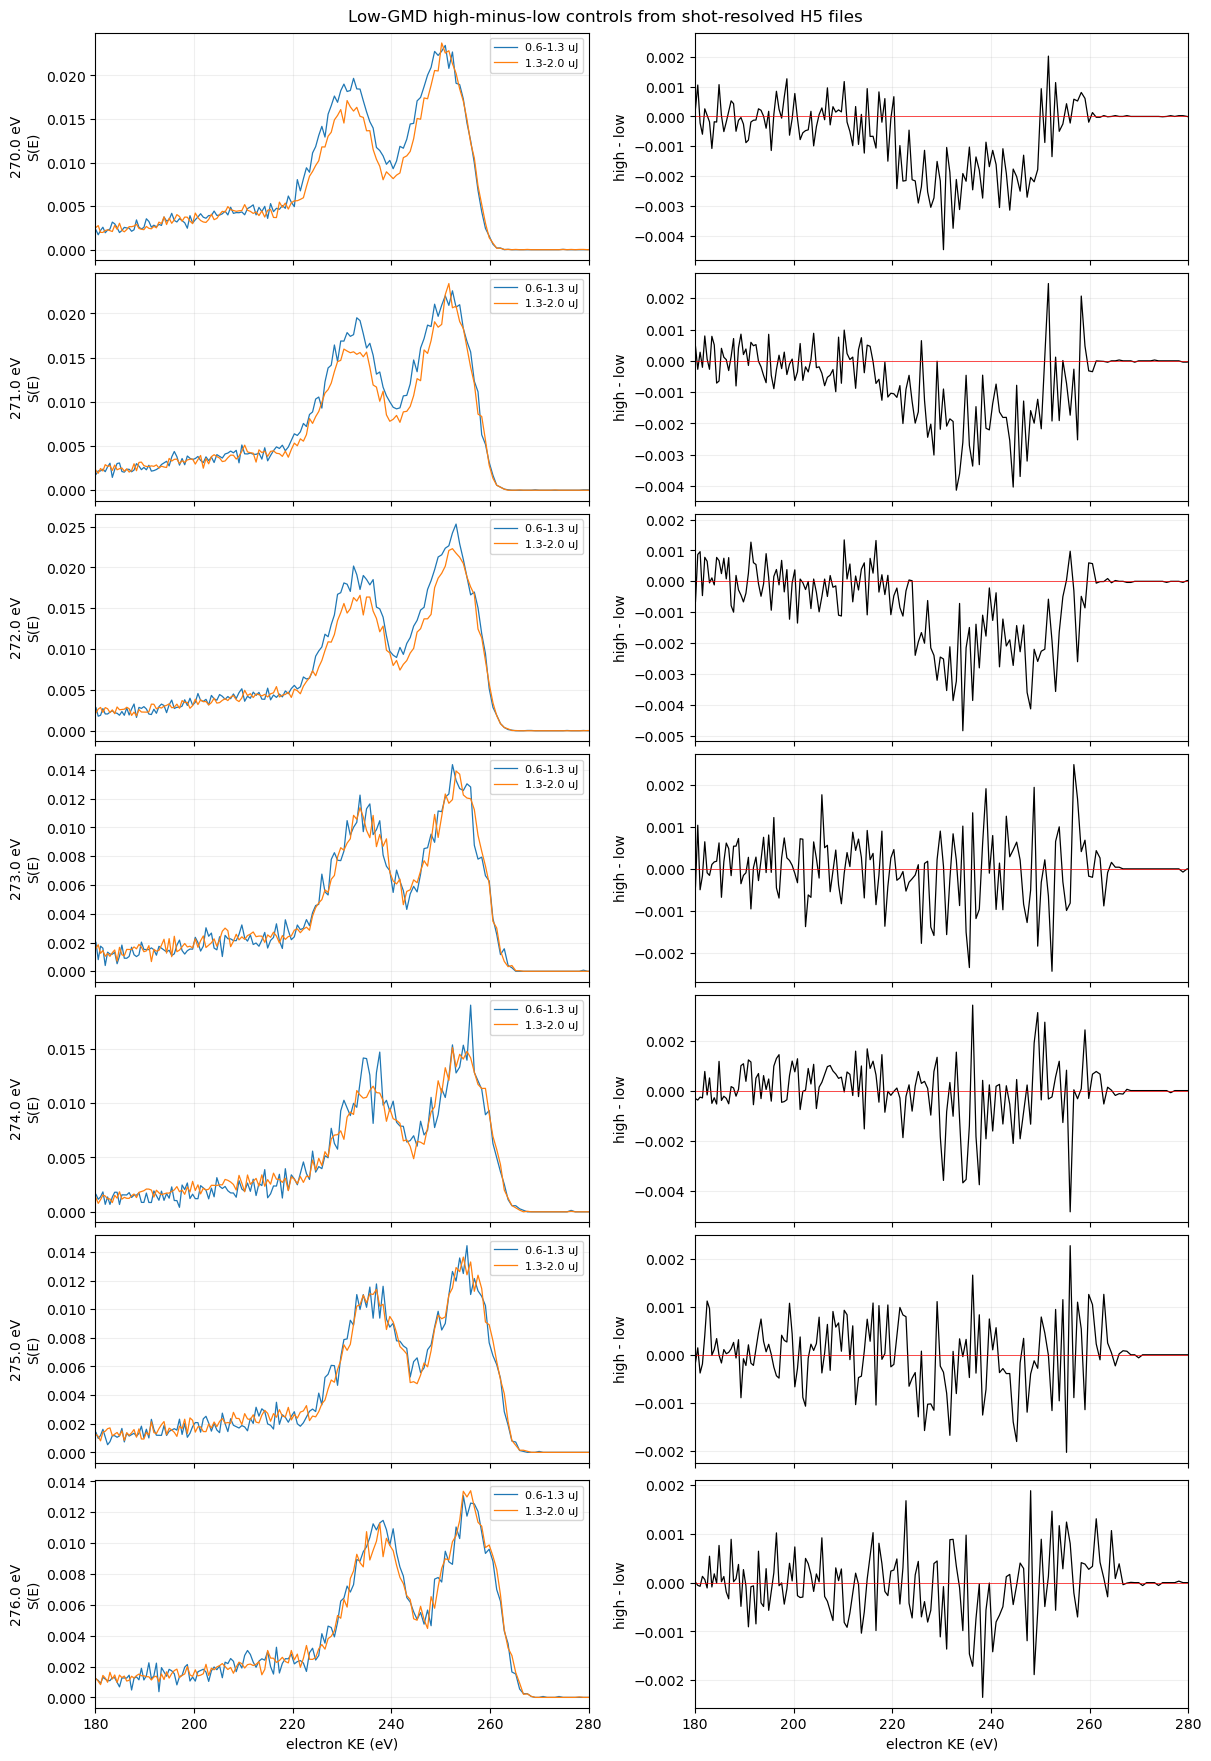

In [23]:
n = len(control_results)
fig, axes = plt.subplots(
    n,
    2,
    figsize=(12, 2.5 * n),
    sharex=True,
    constrained_layout=True,
)

axes = np.atleast_2d(axes)

for row, (energy, r) in enumerate(sorted(control_results.items())):
    tof_edges = r["tof_edges"]

    ke_low, y_low = tof_spectrum_to_ke_density(tof_edges, r["low"]["spectrum"], TOF_RANGE)
    ke_high, y_high = tof_spectrum_to_ke_density(tof_edges, r["high"]["spectrum"], TOF_RANGE)
    ke_diff, y_diff = tof_spectrum_to_ke_density(tof_edges, r["diff"], TOF_RANGE)

    ax0, ax1 = axes[row]

    ax0.plot(ke_low, y_low, lw=0.9, label=f"{LOW_GMD_RANGE[0]}-{LOW_GMD_RANGE[1]} uJ")
    ax0.plot(ke_high, y_high, lw=0.9, label=f"{HIGH_GMD_RANGE[0]}-{HIGH_GMD_RANGE[1]} uJ")
    ax0.set_ylabel(f"{energy:.1f} eV\nS(E)")
    ax0.grid(alpha=0.2)
    ax0.legend(fontsize=8)

    ax1.plot(ke_diff, y_diff, lw=0.9, color="k")
    ax1.axhline(0.0, color="r", lw=0.7, alpha=0.7)
    ax1.set_ylabel("high - low")
    ax1.grid(alpha=0.2)

axes[-1, 0].set_xlabel("electron KE (eV)")
axes[-1, 1].set_xlabel("electron KE (eV)")

for ax in axes.ravel():
    ax.set_xlim(KE_XLIM)

fig.suptitle("Low-GMD high-minus-low controls from shot-resolved H5 files")
plt.show()

In [24]:
full_rows = []

tof_edges_ref = None

for agg_path, energy in files:
    print(f"Processing {energy:8.3f} eV  {agg_path.name}")

    try:
        r = low_high_from_aggregate_source(agg_path)
    except Exception as exc:
        print(f"  skipped: {exc}")
        continue

    if tof_edges_ref is None:
        tof_edges_ref = r["tof_edges"]
    elif not np.array_equal(tof_edges_ref, r["tof_edges"]):
        print("  skipped: TOF edges mismatch")
        continue

    low = r["low"]
    high = r["high"]

    usable = (
        low["shots"] >= MIN_SHOTS_PER_GROUP
        and high["shots"] >= MIN_SHOTS_PER_GROUP
        and low["sum_gmd"] >= MIN_SUM_GMD_PER_GROUP
        and high["sum_gmd"] >= MIN_SUM_GMD_PER_GROUP
    )

    low_hpg = low["hits"] / low["sum_gmd"] if low["sum_gmd"] > 0 else np.nan
    high_hpg = high["hits"] / high["sum_gmd"] if high["sum_gmd"] > 0 else np.nan

    full_rows.append({
        "energy": float(energy),
        "path": agg_path,
        "source_h5": r["source_h5"],
        "low": low,
        "high": high,
        "diff": r["diff"],
        "frac": r["frac"],
        "usable": usable,
        "low_hits_per_gmd": low_hpg,
        "high_hits_per_gmd": high_hpg,
    })

    print(
        f"  usable={usable}  "
        f"low shots={low['shots']:8d}, high shots={high['shots']:8d}, "
        f"hits/GMD {low_hpg:.5g} -> {high_hpg:.5g}"
    )

print()
print(f"Built {len(full_rows)} rows")
print(f"Usable rows: {sum(r['usable'] for r in full_rows)}")

Processing  270.000 eV  glycine_WL_scan_270.0eV_aggregates_etof1.h5
  usable=True  low shots=   36318, high shots=   28764, hits/GMD 1.6463 -> 1.6175
Processing  270.500 eV  glycine_WL_scan_270.5eV_aggregates_etof1.h5
  usable=True  low shots=   24280, high shots=   26425, hits/GMD 1.4639 -> 1.44
Processing  271.000 eV  glycine_WL_scan_271.0eV_aggregates_etof1.h5
  usable=True  low shots=   32287, high shots=   28502, hits/GMD 1.5839 -> 1.541
Processing  271.500 eV  glycine_WL_scan_271.5eV_aggregates_etof1.h5
  usable=True  low shots=   29078, high shots=   28138, hits/GMD 1.5135 -> 1.4732
Processing  272.000 eV  glycine_WL_scan_272.0eV_aggregates_etof1.h5
  usable=True  low shots=   38638, high shots=   30470, hits/GMD 1.6209 -> 1.5729
Processing  272.500 eV  glycine_WL_scan_272.5eV_aggregates_etof1.h5
  usable=True  low shots=   36476, high shots=   32540, hits/GMD 1.3459 -> 1.3075
Processing  273.000 eV  glycine_WL_scan_273.0eV_aggregates_etof1.h5
  usable=True  low shots=   16482, 

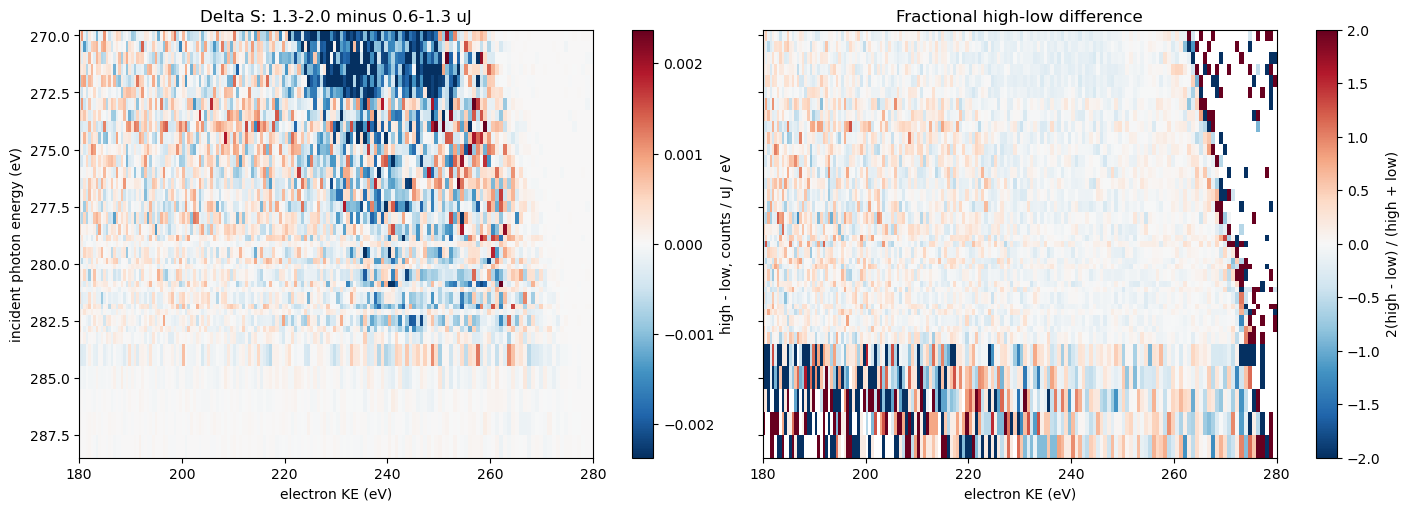

In [25]:
USE_ONLY_USABLE_ROWS = True

rows_to_plot = [r for r in full_rows if (r["usable"] or not USE_ONLY_USABLE_ROWS)]

energies_map = np.array([r["energy"] for r in rows_to_plot], dtype=float)
diff_map_tof = np.vstack([r["diff"] for r in rows_to_plot])
frac_map_tof = np.vstack([r["frac"] for r in rows_to_plot])

# If duplicate photon energies exist, pcolormesh cannot represent them cleanly.
# This keeps all runs but gives exact duplicates tiny plotting offsets only.
energies_plot = energies_map.copy()
seen = {}
for i, e in enumerate(energies_plot):
    key = round(float(e), 6)
    count = seen.get(key, 0)
    seen[key] = count + 1
    if count > 0:
        energies_plot[i] += 1e-3 * count

order_e = np.argsort(energies_plot)
energies_plot = energies_plot[order_e]
energies_map = energies_map[order_e]
diff_map_tof = diff_map_tof[order_e]
frac_map_tof = frac_map_tof[order_e]

ke_edges_map, diff_map_ke = _tof_window_to_ke_edges_and_data(
    tof_edges_ref,
    diff_map_tof,
    TOF_RANGE,
)

_, frac_map_ke = _tof_window_to_ke_edges_and_data(
    tof_edges_ref,
    frac_map_tof,
    TOF_RANGE,
)

# _tof_window_to_ke_edges_and_data divides by dKE, which is correct for diff,
# but not for a dimensionless ratio/fraction. Undo that for frac_map_ke.
ke_widths = np.abs(np.diff(ke_edges_map))
frac_map_ke = frac_map_ke * ke_widths[None, :]

e_edges_map = half_step_edges(energies_plot)

diff_finite = diff_map_ke[np.isfinite(diff_map_ke)]
diff_lim = np.nanpercentile(np.abs(diff_finite), 99.0)
diff_norm = TwoSlopeNorm(vmin=-diff_lim, vcenter=0.0, vmax=diff_lim)

frac_finite = frac_map_ke[np.isfinite(frac_map_ke)]
frac_lim = np.nanpercentile(np.abs(frac_finite), 99.0)
frac_norm = TwoSlopeNorm(vmin=-frac_lim, vcenter=0.0, vmax=frac_lim)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True, constrained_layout=True)

pcm0 = axes[0].pcolormesh(
    ke_edges_map,
    e_edges_map,
    diff_map_ke,
    shading="auto",
    cmap="RdBu_r",
    norm=diff_norm,
)
fig.colorbar(pcm0, ax=axes[0], label="high - low, counts / uJ / eV")

axes[0].set_title(
    f"Delta S: {HIGH_GMD_RANGE[0]}-{HIGH_GMD_RANGE[1]} minus "
    f"{LOW_GMD_RANGE[0]}-{LOW_GMD_RANGE[1]} uJ"
)
axes[0].set_xlabel("electron KE (eV)")
axes[0].set_ylabel("incident photon energy (eV)")
axes[0].set_xlim(KE_XLIM)

pcm1 = axes[1].pcolormesh(
    ke_edges_map,
    e_edges_map,
    frac_map_ke,
    shading="auto",
    cmap="RdBu_r",
    norm=frac_norm,
)
fig.colorbar(pcm1, ax=axes[1], label="2(high - low) / (high + low)")

axes[1].set_title("Fractional high-low difference")
axes[1].set_xlabel("electron KE (eV)")
axes[1].set_xlim(KE_XLIM)

axes[0].set_ylim(np.nanmax(e_edges_map), np.nanmin(e_edges_map))

plt.show()

In [26]:
for r in full_rows:
    r["family"] = scan_family_from_filename(r["path"])

print("Rows by family:")
for family in ["floating", "integer", "unknown"]:
    rows = [r for r in full_rows if r["family"] == family]
    if not rows:
        continue

    e = np.array([r["energy"] for r in rows])
    usable = np.array([r["usable"] for r in rows])

    print()
    print(f"{family}: {len(rows)} rows, {usable.sum()} usable")
    print(f"  energy range: {np.nanmin(e):.3f} to {np.nanmax(e):.3f} eV")
    for r in rows:
        print(
            f"  {r['energy']:8.3f} eV  usable={r['usable']}  "
            f"{Path(r['path']).name}"
        )

Rows by family:

floating: 27 rows, 27 usable
  energy range: 270.000 to 283.000 eV
   270.000 eV  usable=True  glycine_WL_scan_270.0eV_aggregates_etof1.h5
   270.500 eV  usable=True  glycine_WL_scan_270.5eV_aggregates_etof1.h5
   271.000 eV  usable=True  glycine_WL_scan_271.0eV_aggregates_etof1.h5
   271.500 eV  usable=True  glycine_WL_scan_271.5eV_aggregates_etof1.h5
   272.000 eV  usable=True  glycine_WL_scan_272.0eV_aggregates_etof1.h5
   272.500 eV  usable=True  glycine_WL_scan_272.5eV_aggregates_etof1.h5
   273.000 eV  usable=True  glycine_WL_scan_273.0eV_aggregates_etof1.h5
   273.500 eV  usable=True  glycine_WL_scan_273.5eV_aggregates_etof1.h5
   274.000 eV  usable=True  glycine_WL_scan_274.0eV_aggregates_etof1.h5
   274.500 eV  usable=True  glycine_WL_scan_274.5eV_aggregates_etof1.h5
   275.000 eV  usable=True  glycine_WL_scan_275.0eV_aggregates_etof1.h5
   275.500 eV  usable=True  glycine_WL_scan_275.5eV_aggregates_etof1.h5
   276.000 eV  usable=True  glycine_WL_scan_276.0eV_

In [27]:
FRAC_DENOM_MIN = 1e-4

def plot_family_difference_maps(
    full_rows,
    family,
    *,
    use_only_usable=True,
    tof_edges_ref=tof_edges_ref,
    tof_range=TOF_RANGE,
    ke_xlim=KE_XLIM,
    diff_vlim=None,
    frac_vlim=0.5,
):
    rows = [
        r for r in full_rows
        if r.get("family") == family and (r["usable"] or not use_only_usable)
    ]

    if not rows:
        print(f"No rows to plot for family={family!r}")
        return None

    rows = sorted(rows, key=lambda r: (r["energy"], Path(r["path"]).name))

    energies = np.array([r["energy"] for r in rows], dtype=float)
    diff_map_tof = np.vstack([r["diff"] for r in rows])
    frac_map_tof = np.vstack([r["frac"] for r in rows])

    ke_edges, diff_map_ke = _tof_window_to_ke_edges_and_data(
        tof_edges_ref,
        diff_map_tof,
        tof_range,
    )

    # Fractional map is dimensionless, so convert x-axis to KE but do NOT keep /dKE.
    _, frac_map_ke_density_wrong_units = _tof_window_to_ke_edges_and_data(
        tof_edges_ref,
        frac_map_tof,
        tof_range,
    )
    ke_widths = np.abs(np.diff(ke_edges))
    frac_map_ke = frac_map_ke_density_wrong_units * ke_widths[None, :]

    # Mask unstable fractional pixels instead of clipping them.
    denom_tof = np.vstack([
        r["high"]["spectrum"] + r["low"]["spectrum"]
        for r in rows
    ])

    _, denom_ke_density_wrong_units = _tof_window_to_ke_edges_and_data(
        tof_edges_ref,
        denom_tof,
        tof_range,
    )
    denom_ke = denom_ke_density_wrong_units * ke_widths[None, :]

    denom_min = FRAC_DENOM_MIN if "FRAC_DENOM_MIN" in globals() else 1e-4
    frac_map_ke[denom_ke < denom_min] = np.nan
    frac_map_ke[np.abs(frac_map_ke) > 2.0] = np.nan

    e_edges = half_step_edges(energies)

    if diff_vlim is None:
        finite = diff_map_ke[np.isfinite(diff_map_ke)]
        diff_vlim = float(np.nanpercentile(np.abs(finite), 99.0)) if finite.size else 1.0

    finite_frac = frac_map_ke[np.isfinite(frac_map_ke)]
    if frac_vlim is None:
        frac_vlim = float(np.nanpercentile(np.abs(finite_frac), 99.0)) if finite_frac.size else 0.5
        frac_vlim = min(frac_vlim, 2.0)
    else:
        frac_vlim = min(float(frac_vlim), 2.0)

    diff_norm = TwoSlopeNorm(vmin=-diff_vlim, vcenter=0.0, vmax=diff_vlim)
    frac_norm = TwoSlopeNorm(vmin=-frac_vlim, vcenter=0.0, vmax=frac_vlim)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(14, 5),
        sharey=True,
        constrained_layout=True,
    )

    pcm0 = axes[0].pcolormesh(
        ke_edges,
        e_edges,
        diff_map_ke,
        shading="auto",
        cmap="RdBu_r",
        norm=diff_norm,
    )
    fig.colorbar(pcm0, ax=axes[0], label="high - low, counts / uJ / eV")

    axes[0].set_title(
        f"{family}: Delta S\n"
        f"{HIGH_GMD_RANGE[0]}-{HIGH_GMD_RANGE[1]} minus "
        f"{LOW_GMD_RANGE[0]}-{LOW_GMD_RANGE[1]} uJ"
    )
    axes[0].set_xlabel("electron KE (eV)")
    axes[0].set_ylabel("incident photon energy (eV)")

    pcm1 = axes[1].pcolormesh(
        ke_edges,
        e_edges,
        frac_map_ke,
        shading="auto",
        cmap="RdBu_r",
        norm=frac_norm,
    )
    fig.colorbar(
        pcm1,
        ax=axes[1],
        label="2(high - low) / (high + low)",
    )

    axes[1].set_title(f"{family}: fractional Delta S")
    axes[1].set_xlabel("electron KE (eV)")

    for ax in axes:
        if ke_xlim is not None:
            ax.set_xlim(ke_xlim)
        ax.grid(False)

    axes[0].set_ylim(np.nanmax(e_edges), np.nanmin(e_edges))

    plt.show()

    print(f"{family} rows plotted:")
    for r in rows:
        low = r["low"]
        high = r["high"]
        low_hpg = low["hits"] / low["sum_gmd"] if low["sum_gmd"] > 0 else np.nan
        high_hpg = high["hits"] / high["sum_gmd"] if high["sum_gmd"] > 0 else np.nan
        print(
            f"  {r['energy']:8.3f} eV  "
            f"low shots={low['shots']:8d}, high shots={high['shots']:8d}, "
            f"hits/GMD {low_hpg:.5g} -> {high_hpg:.5g}, "
            f"{Path(r['path']).name}"
        )

    return fig, axes

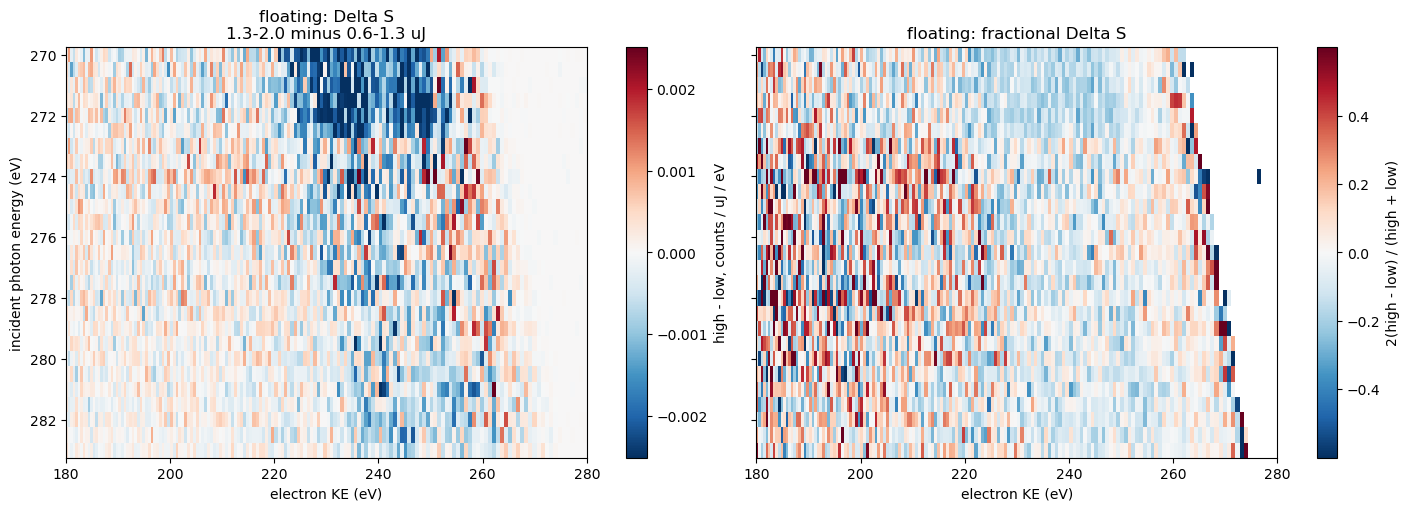

floating rows plotted:
   270.000 eV  low shots=   36318, high shots=   28764, hits/GMD 1.6463 -> 1.6175, glycine_WL_scan_270.0eV_aggregates_etof1.h5
   270.500 eV  low shots=   24280, high shots=   26425, hits/GMD 1.4639 -> 1.44, glycine_WL_scan_270.5eV_aggregates_etof1.h5
   271.000 eV  low shots=   32287, high shots=   28502, hits/GMD 1.5839 -> 1.541, glycine_WL_scan_271.0eV_aggregates_etof1.h5
   271.500 eV  low shots=   29078, high shots=   28138, hits/GMD 1.5135 -> 1.4732, glycine_WL_scan_271.5eV_aggregates_etof1.h5
   272.000 eV  low shots=   38638, high shots=   30470, hits/GMD 1.6209 -> 1.5729, glycine_WL_scan_272.0eV_aggregates_etof1.h5
   272.500 eV  low shots=   36476, high shots=   32540, hits/GMD 1.3459 -> 1.3075, glycine_WL_scan_272.5eV_aggregates_etof1.h5
   273.000 eV  low shots=   16482, high shots=   19525, hits/GMD 0.87879 -> 0.90882, glycine_WL_scan_273.0eV_aggregates_etof1.h5
   273.500 eV  low shots=   21706, high shots=   20519, hits/GMD 1.0631 -> 1.0776, glycin

(<Figure size 1400x500 with 4 Axes>,
 array([<Axes: title={'center': 'floating: Delta S\n1.3-2.0 minus 0.6-1.3 uJ'}, xlabel='electron KE (eV)', ylabel='incident photon energy (eV)'>,
        <Axes: title={'center': 'floating: fractional Delta S'}, xlabel='electron KE (eV)'>],
       dtype=object))

In [28]:
# These are the .0 / .5 / generally decimal-token files.
# They have the higher signal, so allow a larger absolute DeltaS range.

plot_family_difference_maps(
    full_rows,
    "floating",
    use_only_usable=True,
    diff_vlim=None,   # auto per family
    frac_vlim=0.6,    # must be <= 2; lower makes subtle structure visible
)

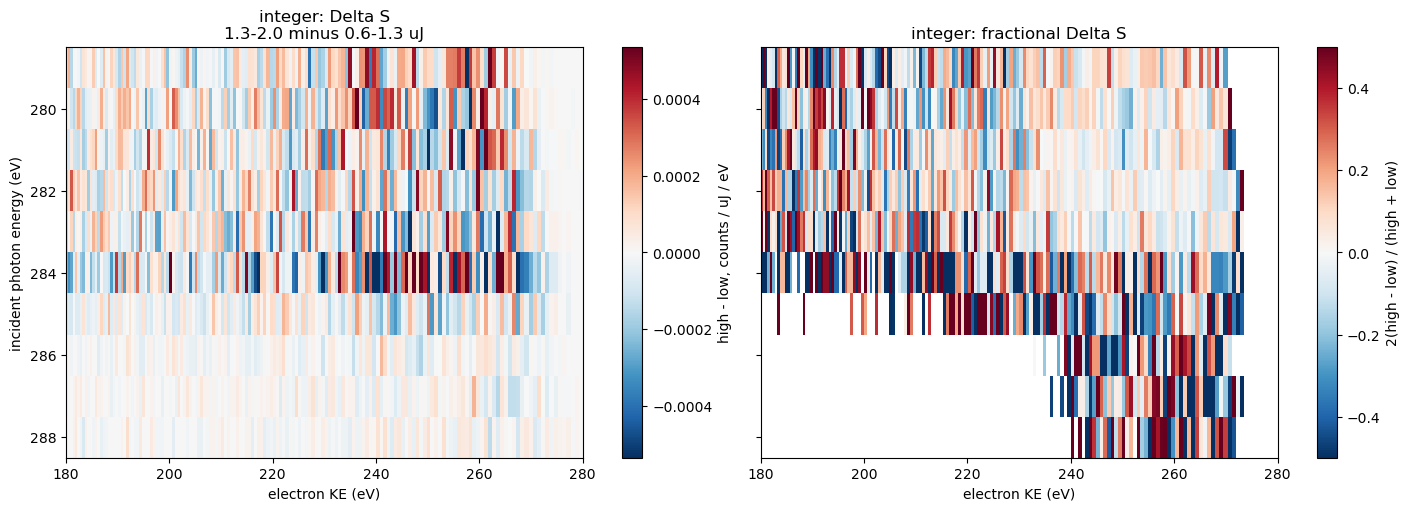

integer rows plotted:
   279.000 eV  low shots=   83936, high shots=   75580, hits/GMD 0.18899 -> 0.1961, glycine_WL_scan_279eV_aggregates_etof1.h5
   280.000 eV  low shots=   86911, high shots=   77891, hits/GMD 0.27885 -> 0.2836, glycine_WL_scan_280eV_aggregates_etof1.h5
   281.000 eV  low shots=   99326, high shots=   82345, hits/GMD 0.34132 -> 0.33164, glycine_WL_scan_281eV_aggregates_etof1.h5
   282.000 eV  low shots=  125160, high shots=   94476, hits/GMD 0.34646 -> 0.35017, glycine_WL_scan_282eV_aggregates_etof1.h5
   283.000 eV  low shots=  105148, high shots=   56960, hits/GMD 0.27644 -> 0.2788, glycine_WL_scan_283eV_aggregates_etof1.h5
   284.000 eV  low shots=   63997, high shots=    7406, hits/GMD 0.15932 -> 0.16432, glycine_WL_scan_284eV_aggregates_etof1.h5
   285.000 eV  low shots=  106725, high shots=   32647, hits/GMD 0.050982 -> 0.047222, glycine_WL_scan_285eV_aggregates_etof1.h5
   286.000 eV  low shots=  108079, high shots=   48188, hits/GMD 0.016995 -> 0.014698, gly

(<Figure size 1400x500 with 4 Axes>,
 array([<Axes: title={'center': 'integer: Delta S\n1.3-2.0 minus 0.6-1.3 uJ'}, xlabel='electron KE (eV)', ylabel='incident photon energy (eV)'>,
        <Axes: title={'center': 'integer: fractional Delta S'}, xlabel='electron KE (eV)'>],
       dtype=object))

In [29]:
# These are the integer-token files, lower-temperature/lower-signal dataset.
# Use separate auto scaling so the lower signal is visible.

plot_family_difference_maps(
    full_rows,
    "integer",
    use_only_usable=True,
    diff_vlim=None,   # auto per family, independent of floating map
    frac_vlim=0.5,
)

#### Investigating the possible resonance

In [39]:
# Choose these after looking at the 2D maps.
# Suspected scattered-electron feature:
FEATURE_KE_RANGE = (190, 220)

# Nearby reference/background KE region.
# Pick something close in KE but not on the suspected band.
BACKGROUND_KE_RANGE = (180, 190)

TRACE_FAMILY = "floating"   # "floating" or "integer"
USE_ONLY_USABLE_ROWS = True


WINDOW_FAMILY = "floating"   # "floating" or "integer"
USE_ONLY_USABLE_ROWS = True

# Adjacent windows, deliberately not fitted or smoothed.
KE_TRACE_WINDOWS = [
    (180, 190),
    (190, 200),
    (200, 210),
    (210, 220),
    (220,225),
    (220, 230), 
    # (190, 210),
    # (200, 220),
    # (195, 215)
   # (230, 240),
]

def ke_window_weights_for_tof_bins(tof_edges, ke_range):
    ke_edges = tof_to_ke(tof_edges)

    lo = np.minimum(ke_edges[:-1], ke_edges[1:])
    hi = np.maximum(ke_edges[:-1], ke_edges[1:])
    width = hi - lo

    k0, k1 = ke_range
    overlap = np.maximum(0.0, np.minimum(hi, k1) - np.maximum(lo, k0))

    weights = np.zeros_like(width, dtype=float)
    good = np.isfinite(lo) & np.isfinite(hi) & (width > 0)
    weights[good] = overlap[good] / width[good]
    return weights


def integrate_group_with_uncertainty(group, tof_edges, ke_range):
    """
    Integrate S(E)=counts/GMD over a KE window.

    Returns:
      value: counts/uJ
      sigma: propagated Poisson uncertainty, counts/uJ
      raw_counts: weighted counts entering the integral
    """
    w = ke_window_weights_for_tof_bins(tof_edges, ke_range)

    counts = np.asarray(group["counts"], dtype=float)
    sum_gmd = float(group["sum_gmd"])

    weighted_counts = float(np.nansum(w * counts))
    var_counts = float(np.nansum((w ** 2) * np.maximum(counts, 0.0)))

    if sum_gmd <= 0:
        return np.nan, np.nan, weighted_counts

    value = weighted_counts / sum_gmd
    sigma = np.sqrt(var_counts) / sum_gmd
    return value, sigma, weighted_counts


def build_window_traces(full_rows, family, ke_windows, *, use_only_usable=True):
    rows = [
        r for r in full_rows
        if r.get("family") == family and (r["usable"] or not use_only_usable)
    ]
    rows = sorted(rows, key=lambda r: (r["energy"], Path(r["path"]).name))

    out = {
        "rows": rows,
        "energies": np.array([r["energy"] for r in rows], dtype=float),
        "windows": ke_windows,
        "delta": {},
        "sigma": {},
        "low": {},
        "high": {},
        "low_counts": {},
        "high_counts": {},
    }

    for ke_range in ke_windows:
        delta_vals = []
        sigma_vals = []
        low_vals = []
        high_vals = []
        low_counts = []
        high_counts = []

        for r in rows:
            y_low, sig_low, c_low = integrate_group_with_uncertainty(
                r["low"], tof_edges_ref, ke_range
            )
            y_high, sig_high, c_high = integrate_group_with_uncertainty(
                r["high"], tof_edges_ref, ke_range
            )

            delta_vals.append(y_high - y_low)
            sigma_vals.append(np.sqrt(sig_low ** 2 + sig_high ** 2))
            low_vals.append(y_low)
            high_vals.append(y_high)
            low_counts.append(c_low)
            high_counts.append(c_high)

        out["delta"][ke_range] = np.array(delta_vals, dtype=float)
        out["sigma"][ke_range] = np.array(sigma_vals, dtype=float)
        out["low"][ke_range] = np.array(low_vals, dtype=float)
        out["high"][ke_range] = np.array(high_vals, dtype=float)
        out["low_counts"][ke_range] = np.array(low_counts, dtype=float)
        out["high_counts"][ke_range] = np.array(high_counts, dtype=float)

    return out


trace_windows = build_window_traces(
    full_rows,
    WINDOW_FAMILY,
    KE_TRACE_WINDOWS,
    use_only_usable=USE_ONLY_USABLE_ROWS,
)

print(f"Built KE-window traces for family: {WINDOW_FAMILY}")
print("Rows:")
for r in trace_windows["rows"]:
    print(
        f"  {r['energy']:8.3f} eV  "
        f"low shots={r['low']['shots']:8d}, high shots={r['high']['shots']:8d}, "
        f"low GMD={r['low']['sum_gmd']:10.4g}, high GMD={r['high']['sum_gmd']:10.4g}, "
        f"{Path(r['path']).name}"
    )


def ke_window_weights_from_edges(ke_edges, ke_min, ke_max):
    """
    Fractional overlap weights for an unequal KE-edge grid.
    Returns one weight per KE bin.
    """
    ke_edges = np.asarray(ke_edges, dtype=float)

    lo = np.minimum(ke_edges[:-1], ke_edges[1:])
    hi = np.maximum(ke_edges[:-1], ke_edges[1:])
    width = hi - lo

    overlap = np.maximum(
        0.0,
        np.minimum(hi, ke_max) - np.maximum(lo, ke_min),
    )

    weights = np.zeros_like(width)
    good = np.isfinite(lo) & np.isfinite(hi) & (width > 0)
    weights[good] = overlap[good] / width[good]
    return weights


def build_family_ke_maps(
    full_rows,
    family,
    *,
    use_only_usable=True,
    tof_edges_ref=tof_edges_ref,
    tof_range=TOF_RANGE,
):
    rows = [
        r for r in full_rows
        if r.get("family") == family and (r["usable"] or not use_only_usable)
    ]

    if not rows:
        raise ValueError(f"No rows for family={family!r}")

    rows = sorted(rows, key=lambda r: (r["energy"], Path(r["path"]).name))

    energies = np.array([r["energy"] for r in rows], dtype=float)
    low_map_tof = np.vstack([r["low"]["spectrum"] for r in rows])
    high_map_tof = np.vstack([r["high"]["spectrum"] for r in rows])
    diff_map_tof = np.vstack([r["diff"] for r in rows])

    ke_edges, low_map_ke = _tof_window_to_ke_edges_and_data(
        tof_edges_ref,
        low_map_tof,
        tof_range,
    )
    _, high_map_ke = _tof_window_to_ke_edges_and_data(
        tof_edges_ref,
        high_map_tof,
        tof_range,
    )
    _, diff_map_ke = _tof_window_to_ke_edges_and_data(
        tof_edges_ref,
        diff_map_tof,
        tof_range,
    )

    return {
        "rows": rows,
        "energies": energies,
        "ke_edges": ke_edges,
        "low": low_map_ke,
        "high": high_map_ke,
        "diff": diff_map_ke,
    }


def integrate_ke_window(map_ke_density, ke_edges, ke_range):
    """
    Integrate a counts/uJ/eV map over a KE window.
    Output units: counts/uJ.
    """
    weights = ke_window_weights_from_edges(ke_edges, ke_range[0], ke_range[1])
    widths = np.abs(np.diff(ke_edges))
    return np.nansum(map_ke_density * weights[None, :] * widths[None, :], axis=1)


trace_data = build_family_ke_maps(
    full_rows,
    TRACE_FAMILY,
    use_only_usable=USE_ONLY_USABLE_ROWS,
)

energies_trace = trace_data["energies"]
ke_edges_trace = trace_data["ke_edges"]

R_feature = integrate_ke_window(
    trace_data["diff"],
    ke_edges_trace,
    FEATURE_KE_RANGE,
)

R_background = integrate_ke_window(
    trace_data["diff"],
    ke_edges_trace,
    BACKGROUND_KE_RANGE,
)

# Also integrate the low/high absolute spectra in the same feature window.
S_low_feature = integrate_ke_window(
    trace_data["low"],
    ke_edges_trace,
    FEATURE_KE_RANGE,
)

S_high_feature = integrate_ke_window(
    trace_data["high"],
    ke_edges_trace,
    FEATURE_KE_RANGE,
)

with np.errstate(invalid="ignore", divide="ignore"):
    frac_feature = 2.0 * (S_high_feature - S_low_feature) / (S_high_feature + S_low_feature)

frac_feature = np.clip(frac_feature, -2.0, 2.0)

print(f"Trace family: {TRACE_FAMILY}")
print(f"Feature KE range   : {FEATURE_KE_RANGE} eV")
print(f"Background KE range: {BACKGROUND_KE_RANGE} eV")
print()
for e, rf, rb, fl in zip(energies_trace, R_feature, R_background, frac_feature):
    print(
        f"{e:8.3f} eV  "
        f"R_feature={rf: .6g}  "
        f"R_background={rb: .6g}  "
        f"frac_feature={fl: .6g}"
    )

Built KE-window traces for family: floating
Rows:
   270.000 eV  low shots=   36318, high shots=   28764, low GMD= 3.352e+04, high GMD= 4.681e+04, glycine_WL_scan_270.0eV_aggregates_etof1.h5
   270.500 eV  low shots=   24280, high shots=   26425, low GMD= 2.313e+04, high GMD= 4.339e+04, glycine_WL_scan_270.5eV_aggregates_etof1.h5
   271.000 eV  low shots=   32287, high shots=   28502, low GMD= 3.007e+04, high GMD= 4.648e+04, glycine_WL_scan_271.0eV_aggregates_etof1.h5
   271.500 eV  low shots=   29078, high shots=   28138, low GMD= 2.728e+04, high GMD= 4.597e+04, glycine_WL_scan_271.5eV_aggregates_etof1.h5
   272.000 eV  low shots=   38638, high shots=   30470, low GMD=  3.57e+04, high GMD= 4.959e+04, glycine_WL_scan_272.0eV_aggregates_etof1.h5
   272.500 eV  low shots=   36476, high shots=   32540, low GMD= 3.401e+04, high GMD= 5.303e+04, glycine_WL_scan_272.5eV_aggregates_etof1.h5
   273.000 eV  low shots=   16482, high shots=   19525, low GMD= 1.574e+04, high GMD= 3.215e+04, glycine

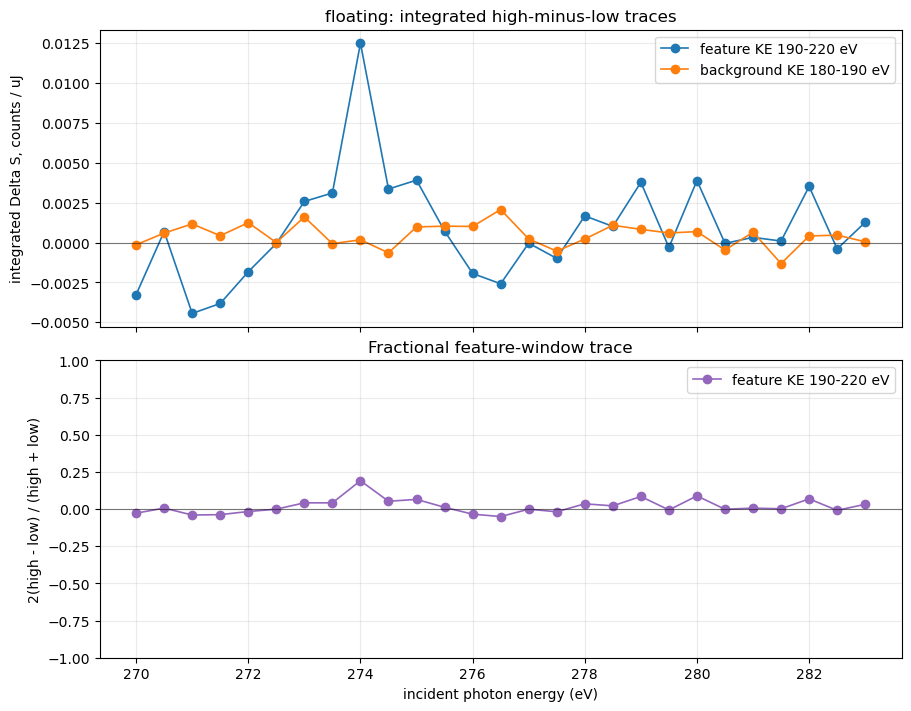

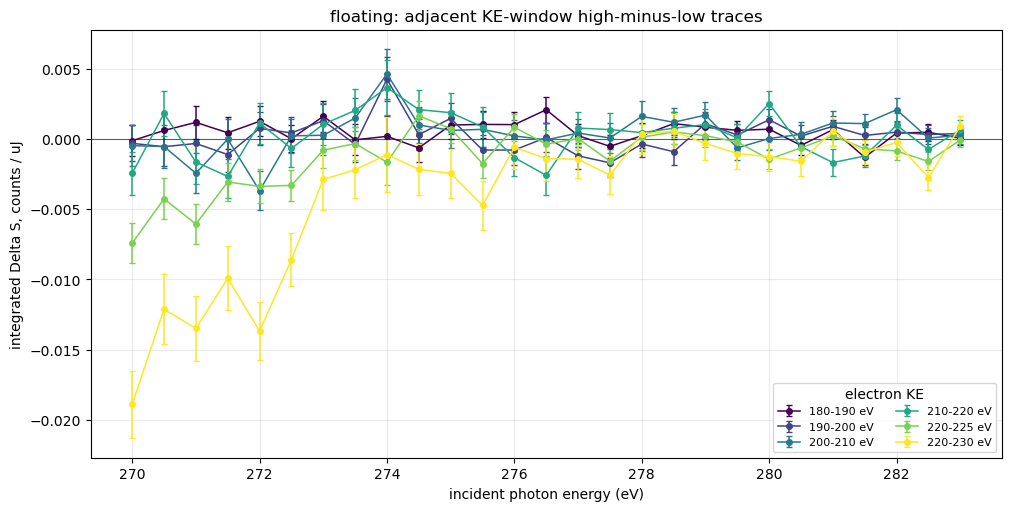

In [40]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True, constrained_layout=True)

axes[0].plot(
    energies_trace,
    R_feature,
    "o-",
    lw=1.2,
    label=f"feature KE {FEATURE_KE_RANGE[0]}-{FEATURE_KE_RANGE[1]} eV",
)

axes[0].plot(
    energies_trace,
    R_background,
    "o-",
    lw=1.2,
    label=f"background KE {BACKGROUND_KE_RANGE[0]}-{BACKGROUND_KE_RANGE[1]} eV",
)

axes[0].axhline(0.0, color="k", lw=0.8, alpha=0.5)
axes[0].set_ylabel("integrated Delta S, counts / uJ")
axes[0].set_title(f"{TRACE_FAMILY}: integrated high-minus-low traces")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].plot(
    energies_trace,
    frac_feature,
    "o-",
    lw=1.2,
    color="tab:purple",
    label=f"feature KE {FEATURE_KE_RANGE[0]}-{FEATURE_KE_RANGE[1]} eV",
)

axes[1].axhline(0.0, color="k", lw=0.8, alpha=0.5)
axes[1].set_xlabel("incident photon energy (eV)")
axes[1].set_ylabel("2(high - low) / (high + low)")
axes[1].set_title("Fractional feature-window trace")
axes[1].set_ylim(-1.0, 1.0)
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.show()

fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(KE_TRACE_WINDOWS)))

for color, ke_range in zip(colors, KE_TRACE_WINDOWS):
    y = trace_windows["delta"][ke_range]
    yerr = trace_windows["sigma"][ke_range]

    ax.errorbar(
        trace_windows["energies"],
        y,
        yerr=yerr,
        fmt="o-",
        ms=4,
        lw=1.1,
        capsize=2,
        color=color,
        label=f"{ke_range[0]}-{ke_range[1]} eV",
    )

ax.axhline(0.0, color="k", lw=0.8, alpha=0.6)
ax.set_xlabel("incident photon energy (eV)")
ax.set_ylabel("integrated Delta S, counts / uJ")
ax.set_title(f"{WINDOW_FAMILY}: adjacent KE-window high-minus-low traces")
ax.grid(alpha=0.25)
ax.legend(title="electron KE", fontsize=8, ncols=2)

plt.show()

Family: floating
Feature window: (190, 220)
Low sideband   : (180, 188)
High sideband  : (220, 225)
Baseline energy ranges: [(270.0, 272.5), (278.0, 283.0)]
alpha: 0.148756

Trace values:
   270.000 eV  feature=-0.00326489  bg=-0.0218058  sub=-2.11523e-05 +/- 0.00256
   270.500 eV  feature= 0.000689912  bg=-0.0110962  sub= 0.00234053 +/- 0.00271
   271.000 eV  feature=-0.00444225  bg=-0.0167279  sub=-0.00195389 +/- 0.00256
   271.500 eV  feature=-0.00381885  bg=-0.00740397  sub=-0.00271746 +/- 0.00253
   272.000 eV  feature=-0.00183073  bg=-0.00663778  sub=-0.000843324 +/- 0.00241
   272.500 eV  feature=-5.95819e-05  bg=-0.0109087  sub= 0.00156315 +/- 0.00219
   273.000 eV  feature= 0.00257485  bg=-0.000248563  sub= 0.00261183 +/- 0.00247
   273.500 eV  feature= 0.00310692  bg=-0.000949188  sub= 0.00324811 +/- 0.00248
   274.000 eV  feature= 0.0124958  bg=-0.00631072  sub= 0.0134346 +/- 0.00316
   274.500 eV  feature= 0.00335335  bg= 0.00352084  sub= 0.00282961 +/- 0.00224
   275.000 e

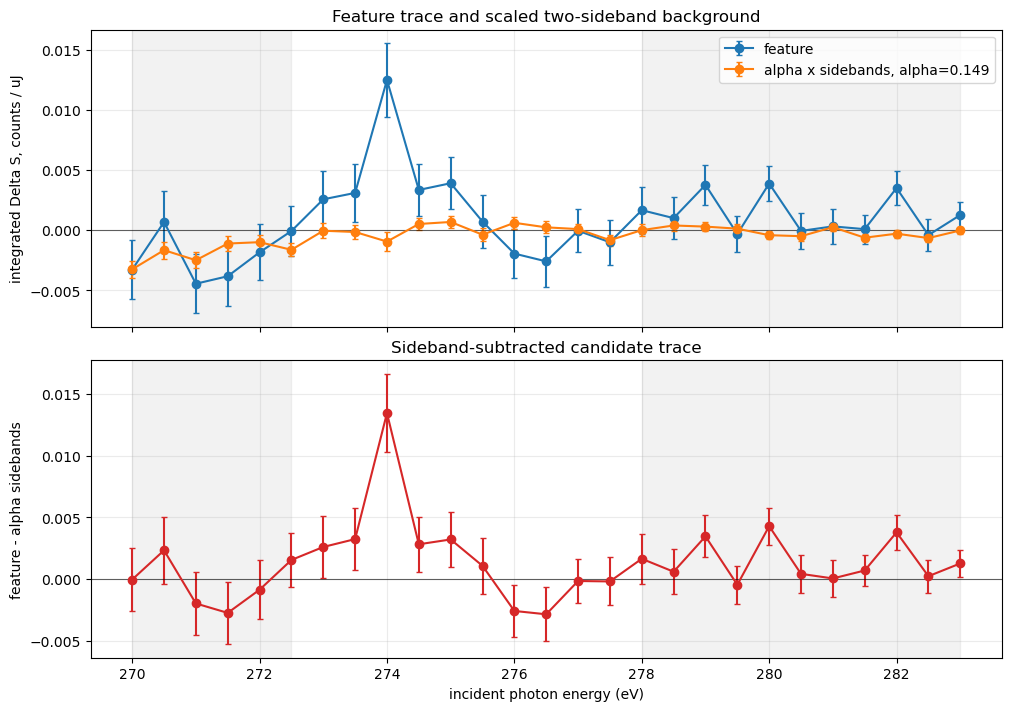

In [32]:
FEATURE_KE_RANGE = (190, 220)
BACKGROUND_LOW_KE_RANGE = (180, 188)
BACKGROUND_HIGH_KE_RANGE = (220, 225)

BASELINE_ENERGY_RANGES = [
    (270.0, 272.5),
    (278.0, 283.0),
]

BASELINE_FAMILY = WINDOW_FAMILY

def energy_mask_from_ranges(energies, ranges):
    mask = np.zeros_like(energies, dtype=bool)
    for lo, hi in ranges:
        mask |= (energies >= lo) & (energies <= hi)
    return mask


sideband_windows = [
    FEATURE_KE_RANGE,
    BACKGROUND_LOW_KE_RANGE,
    BACKGROUND_HIGH_KE_RANGE,
]

sideband_traces = build_window_traces(
    full_rows,
    BASELINE_FAMILY,
    sideband_windows,
    use_only_usable=USE_ONLY_USABLE_ROWS,
)

e = sideband_traces["energies"]

R_feature = sideband_traces["delta"][FEATURE_KE_RANGE]
sig_feature = sideband_traces["sigma"][FEATURE_KE_RANGE]

R_low = sideband_traces["delta"][BACKGROUND_LOW_KE_RANGE]
sig_low = sideband_traces["sigma"][BACKGROUND_LOW_KE_RANGE]

R_high = sideband_traces["delta"][BACKGROUND_HIGH_KE_RANGE]
sig_high = sideband_traces["sigma"][BACKGROUND_HIGH_KE_RANGE]

feature_width = FEATURE_KE_RANGE[1] - FEATURE_KE_RANGE[0]
low_width = BACKGROUND_LOW_KE_RANGE[1] - BACKGROUND_LOW_KE_RANGE[0]
high_width = BACKGROUND_HIGH_KE_RANGE[1] - BACKGROUND_HIGH_KE_RANGE[0]

# Convert sidebands to feature-window-equivalent integrated scale.
R_bg = 0.5 * feature_width * (R_low / low_width + R_high / high_width)
sig_bg = 0.5 * feature_width * np.sqrt(
    (sig_low / low_width) ** 2 + (sig_high / high_width) ** 2
)

baseline_mask = (
    energy_mask_from_ranges(e, BASELINE_ENERGY_RANGES)
    & np.isfinite(R_feature)
    & np.isfinite(R_bg)
)

if np.count_nonzero(baseline_mask) < 2:
    raise ValueError("Not enough off-resonance points to estimate alpha")

# Least-squares alpha from only off-resonance regions.
alpha = np.nansum(R_bg[baseline_mask] * R_feature[baseline_mask]) / np.nansum(
    R_bg[baseline_mask] ** 2
)

R_sub = R_feature - alpha * R_bg
sig_sub = np.sqrt(sig_feature ** 2 + (alpha * sig_bg) ** 2)

print(f"Family: {BASELINE_FAMILY}")
print(f"Feature window: {FEATURE_KE_RANGE}")
print(f"Low sideband   : {BACKGROUND_LOW_KE_RANGE}")
print(f"High sideband  : {BACKGROUND_HIGH_KE_RANGE}")
print(f"Baseline energy ranges: {BASELINE_ENERGY_RANGES}")
print(f"alpha: {alpha:.6g}")
print()
print("Trace values:")
for ee, rf, rb, rs, ss in zip(e, R_feature, R_bg, R_sub, sig_sub):
    print(f"  {ee:8.3f} eV  feature={rf: .6g}  bg={rb: .6g}  sub={rs: .6g} +/- {ss:.3g}")

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)

axes[0].errorbar(e, R_feature, yerr=sig_feature, fmt="o-", capsize=2, label="feature")
axes[0].errorbar(e, alpha * R_bg, yerr=alpha * sig_bg, fmt="o-", capsize=2, label=f"alpha x sidebands, alpha={alpha:.3g}")

for lo, hi in BASELINE_ENERGY_RANGES:
    axes[0].axvspan(lo, hi, color="0.8", alpha=0.25)

axes[0].axhline(0.0, color="k", lw=0.8, alpha=0.6)
axes[0].set_ylabel("integrated Delta S, counts / uJ")
axes[0].set_title("Feature trace and scaled two-sideband background")
axes[0].grid(alpha=0.25)
axes[0].legend()

axes[1].errorbar(e, R_sub, yerr=sig_sub, fmt="o-", capsize=2, color="tab:red")

for lo, hi in BASELINE_ENERGY_RANGES:
    axes[1].axvspan(lo, hi, color="0.8", alpha=0.25)

axes[1].axhline(0.0, color="k", lw=0.8, alpha=0.6)
axes[1].set_xlabel("incident photon energy (eV)")
axes[1].set_ylabel("feature - alpha sidebands")
axes[1].set_title("Sideband-subtracted candidate trace")
axes[1].grid(alpha=0.25)

plt.show()

#### Best selection window

In [42]:
CANDIDATE_FAMILY = "floating"  # or "integer"

BASELINE_ENERGY_RANGES = [
    (270.0, 272.5),
    (278.0, 283.0),
]

REFERENCE_ENERGY_EV = 274.0

CANDIDATE_KE_WINDOWS = [
    (190, 200),
    (200, 210),
    (210, 220),
    (190, 210),
    (200, 220),
    (195, 215),
    (190, 220),
]

BACKGROUND_COMPARISON_KE_RANGE = (180, 190)

candidate_traces = build_window_traces(
    full_rows,
    CANDIDATE_FAMILY,
    CANDIDATE_KE_WINDOWS + [BACKGROUND_COMPARISON_KE_RANGE],
    use_only_usable=USE_ONLY_USABLE_ROWS,
)

e = candidate_traces["energies"]

def mask_energy_ranges(energies, ranges):
    mask = np.zeros_like(energies, dtype=bool)
    for lo, hi in ranges:
        mask |= (energies >= lo) & (energies <= hi)
    return mask

baseline_mask = mask_energy_ranges(e, BASELINE_ENERGY_RANGES)

print(f"Family: {CANDIDATE_FAMILY}")
print(f"Baseline energy ranges: {BASELINE_ENERGY_RANGES}")
print(f"Reference energy: {REFERENCE_ENERGY_EV:.3f} eV")
print()
print("Rows:")
for r in candidate_traces["rows"]:
    print(
        f"  {r['energy']:8.3f} eV  "
        f"low shots={r['low']['shots']:8d}, high shots={r['high']['shots']:8d}, "
        f"low GMD={r['low']['sum_gmd']:10.4g}, high GMD={r['high']['sum_gmd']:10.4g}, "
        f"{Path(r['path']).name}"
    )

Family: floating
Baseline energy ranges: [(270.0, 272.5), (278.0, 283.0)]
Reference energy: 274.000 eV

Rows:
   270.000 eV  low shots=   36318, high shots=   28764, low GMD= 3.352e+04, high GMD= 4.681e+04, glycine_WL_scan_270.0eV_aggregates_etof1.h5
   270.500 eV  low shots=   24280, high shots=   26425, low GMD= 2.313e+04, high GMD= 4.339e+04, glycine_WL_scan_270.5eV_aggregates_etof1.h5
   271.000 eV  low shots=   32287, high shots=   28502, low GMD= 3.007e+04, high GMD= 4.648e+04, glycine_WL_scan_271.0eV_aggregates_etof1.h5
   271.500 eV  low shots=   29078, high shots=   28138, low GMD= 2.728e+04, high GMD= 4.597e+04, glycine_WL_scan_271.5eV_aggregates_etof1.h5
   272.000 eV  low shots=   38638, high shots=   30470, low GMD=  3.57e+04, high GMD= 4.959e+04, glycine_WL_scan_272.0eV_aggregates_etof1.h5
   272.500 eV  low shots=   36476, high shots=   32540, low GMD= 3.401e+04, high GMD= 5.303e+04, glycine_WL_scan_272.5eV_aggregates_etof1.h5
   273.000 eV  low shots=   16482, high shot

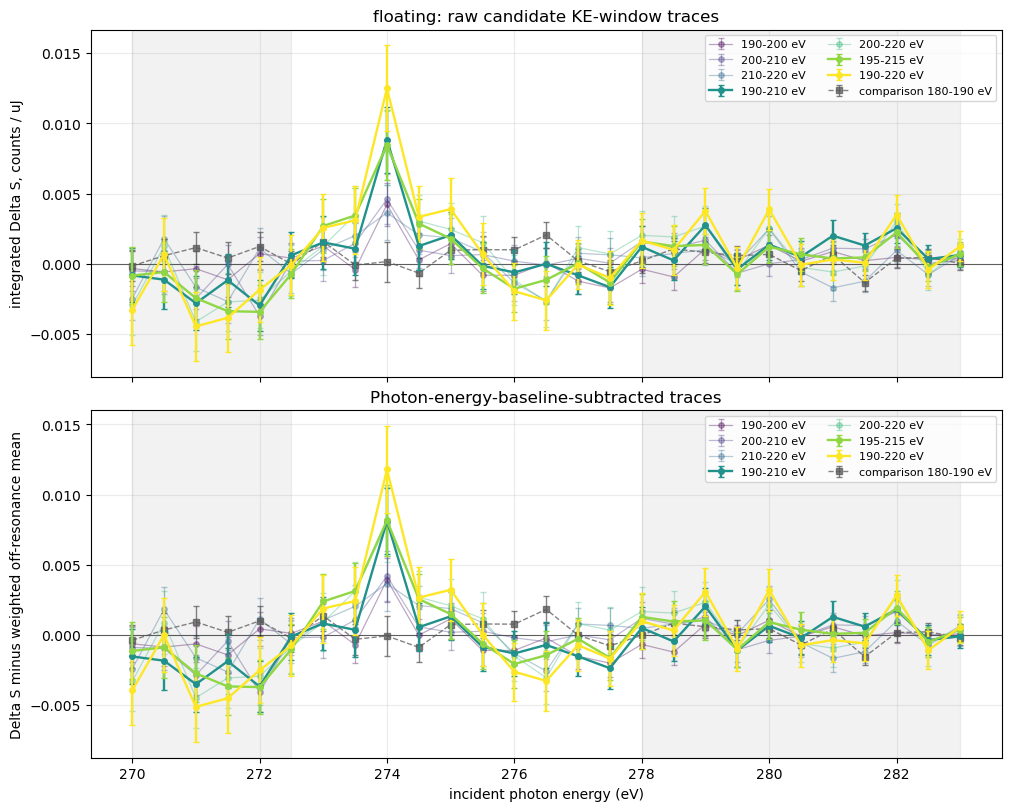

In [43]:
def weighted_baseline_mean(y, yerr, baseline_mask):
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    ok = baseline_mask & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    if np.count_nonzero(ok) < 2:
        return np.nan, np.nan, np.nan, 0

    w = 1.0 / yerr[ok] ** 2
    mean = np.sum(w * y[ok]) / np.sum(w)
    mean_err = np.sqrt(1.0 / np.sum(w))

    # Empirical scatter, kept separate from uncertainty on the mean.
    rms = np.sqrt(np.nanmean((y[ok] - mean) ** 2))

    return mean, mean_err, rms, int(np.count_nonzero(ok))


fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True, constrained_layout=True)

highlight_windows = [(190, 220), (190, 210), (195, 215)]
cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0, 1, len(CANDIDATE_KE_WINDOWS)))

baseline_results = {}

for color, ke_range in zip(colors, CANDIDATE_KE_WINDOWS):
    y = candidate_traces["delta"][ke_range]
    yerr = candidate_traces["sigma"][ke_range]

    off_mean, off_mean_err, off_rms, n_off = weighted_baseline_mean(
        y,
        yerr,
        baseline_mask,
    )

    y_zeroed = y - off_mean
    y_zeroed_err = np.sqrt(yerr**2 + off_mean_err**2)

    baseline_results[ke_range] = {
        "off_mean": off_mean,
        "off_mean_err": off_mean_err,
        "off_rms": off_rms,
        "n_off": n_off,
        "zeroed": y_zeroed,
        "zeroed_err": y_zeroed_err,
    }

    is_highlight = ke_range in highlight_windows
    alpha = 1.0 if is_highlight else 0.35
    lw = 1.7 if is_highlight else 0.9
    zorder = 5 if is_highlight else 2

    axes[0].errorbar(
        e,
        y,
        yerr=yerr,
        fmt="o-",
        ms=4,
        lw=lw,
        capsize=2,
        color=color,
        alpha=alpha,
        zorder=zorder,
        label=f"{ke_range[0]}-{ke_range[1]} eV",
    )

    axes[1].errorbar(
        e,
        y_zeroed,
        yerr=y_zeroed_err,
        fmt="o-",
        ms=4,
        lw=lw,
        capsize=2,
        color=color,
        alpha=alpha,
        zorder=zorder,
        label=f"{ke_range[0]}-{ke_range[1]} eV",
    )

# Comparison window only, not used as subtraction model.
bg = candidate_traces["delta"][BACKGROUND_COMPARISON_KE_RANGE]
bg_sig = candidate_traces["sigma"][BACKGROUND_COMPARISON_KE_RANGE]
bg_mean, bg_mean_err, bg_rms, bg_n = weighted_baseline_mean(bg, bg_sig, baseline_mask)
bg_zeroed = bg - bg_mean
bg_zeroed_err = np.sqrt(bg_sig**2 + bg_mean_err**2)

axes[0].errorbar(
    e,
    bg,
    yerr=bg_sig,
    fmt="s--",
    ms=4,
    lw=1.0,
    capsize=2,
    color="0.35",
    alpha=0.75,
    label=f"comparison {BACKGROUND_COMPARISON_KE_RANGE[0]}-{BACKGROUND_COMPARISON_KE_RANGE[1]} eV",
)

axes[1].errorbar(
    e,
    bg_zeroed,
    yerr=bg_zeroed_err,
    fmt="s--",
    ms=4,
    lw=1.0,
    capsize=2,
    color="0.35",
    alpha=0.75,
    label=f"comparison {BACKGROUND_COMPARISON_KE_RANGE[0]}-{BACKGROUND_COMPARISON_KE_RANGE[1]} eV",
)

for ax in axes:
    ax.axhline(0.0, color="k", lw=0.8, alpha=0.6)
    for lo, hi in BASELINE_ENERGY_RANGES:
        ax.axvspan(lo, hi, color="0.8", alpha=0.25)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8, ncols=2)

axes[0].set_ylabel("integrated Delta S, counts / uJ")
axes[0].set_title(f"{CANDIDATE_FAMILY}: raw candidate KE-window traces")

axes[1].set_xlabel("incident photon energy (eV)")
axes[1].set_ylabel("Delta S minus weighted off-resonance mean")
axes[1].set_title("Photon-energy-baseline-subtracted traces")

plt.show()

In [44]:
def nearest_energy_index(energies, target):
    energies = np.asarray(energies, dtype=float)
    return int(np.nanargmin(np.abs(energies - target)))

i_ref = nearest_energy_index(e, REFERENCE_ENERGY_EV)
e_ref = e[i_ref]

print(f"Reference row: requested {REFERENCE_ENERGY_EV:.3f} eV, using {e_ref:.3f} eV")
print()
print(
    "window        "
    "value@ref        "
    "sigma@ref        "
    "off_wmean       "
    "off_mean_err    "
    "off_rms         "
    "zeroed@ref      "
    "z_counting      "
    "z_with_rms"
)

summary_rows = []

for ke_range in CANDIDATE_KE_WINDOWS:
    y = candidate_traces["delta"][ke_range]
    yerr = candidate_traces["sigma"][ke_range]

    br = baseline_results[ke_range]

    value_ref = y[i_ref]
    sigma_ref = yerr[i_ref]
    off_mean = br["off_mean"]
    off_mean_err = br["off_mean_err"]
    off_rms = br["off_rms"]
    zeroed_ref = value_ref - off_mean

    denom_counting = np.sqrt(sigma_ref**2 + off_mean_err**2)
    z_counting = zeroed_ref / denom_counting if denom_counting > 0 else np.nan

    # Conservative diagnostic: treats observed baseline RMS as extra run-to-run scatter.
    denom_rms = np.sqrt(sigma_ref**2 + off_rms**2)
    z_with_rms = zeroed_ref / denom_rms if denom_rms > 0 else np.nan

    summary_rows.append({
        "ke_range": ke_range,
        "value_ref": value_ref,
        "sigma_ref": sigma_ref,
        "off_mean": off_mean,
        "off_mean_err": off_mean_err,
        "off_rms": off_rms,
        "zeroed_ref": zeroed_ref,
        "z_counting": z_counting,
        "z_with_rms": z_with_rms,
    })

    print(
        f"{ke_range[0]:3.0f}-{ke_range[1]:3.0f} eV  "
        f"{value_ref: .6g}  "
        f"{sigma_ref: .3g}  "
        f"{off_mean: .6g}  "
        f"{off_mean_err: .3g}  "
        f"{off_rms: .3g}  "
        f"{zeroed_ref: .6g}  "
        f"{z_counting: .3g}  "
        f"{z_with_rms: .3g}"
    )

best = max(
    summary_rows,
    key=lambda r: abs(r["z_counting"]) if np.isfinite(r["z_counting"]) else -np.inf,
)

print()
print(
    "Largest absolute counting-stat z: "
    f"{best['ke_range'][0]}-{best['ke_range'][1]} eV, "
    f"z_counting={best['z_counting']:.3g}, "
    f"z_with_rms={best['z_with_rms']:.3g}, "
    f"zeroed@ref={best['zeroed_ref']:.6g}"
)

Reference row: requested 274.000 eV, using 274.000 eV

window        value@ref        sigma@ref        off_wmean       off_mean_err    off_rms         zeroed@ref      z_counting      z_with_rms
190-200 eV   0.00424005   0.00155   0.000318585   0.000201   0.000682   0.00392147   2.51   2.32
200-210 eV   0.00461312   0.00177   0.000422081   0.000224   0.00145   0.00419104   2.35   1.83
210-220 eV   0.00364266   0.00195  -1.03567e-05   0.000253   0.00145   0.00365302   1.86   1.51
190-210 eV   0.00885317   0.00235   0.000738171   0.000301   0.00166   0.008115   3.42   2.82
200-220 eV   0.00825578   0.00263   0.000382431   0.000338   0.00213   0.00787335   2.97   2.33
195-215 eV   0.00848654   0.0025   0.00033023   0.000317   0.00168   0.00815631   3.24   2.71
190-220 eV   0.0124958   0.00306   0.000703817   0.000393   0.00245   0.011792   3.83   3.01

Largest absolute counting-stat z: 190-220 eV, z_counting=3.83, z_with_rms=3.01, zeroed@ref=0.011792


In [45]:
ROBUSTNESS_FAMILY = "floating"
ROBUSTNESS_FEATURE_KE_RANGE = (190, 220)
ROBUSTNESS_REFERENCE_ENERGY = 274.0

ROBUSTNESS_GMD_SPLITS = [
    ((0.6, 1.2), (1.2, 1.8)),
    ((0.75, 1.5), (1.5, 2.25)),
    ((0.5, 1.25), (1.25, 2.0)),
]

ROBUSTNESS_BASELINES = [
    [(270.0, 272.5), (278.0, 283.0)],
    [(270.0, 273.0), (277.5, 283.0)],
]

def build_full_rows_for_gmd_split(gmd_low_range, gmd_high_range, family):
    rows = []

    selected = [
        (p, energy) for p, energy in files
        if scan_family_from_filename(p) == family
    ]

    tof_ref = None

    for agg_path, energy in selected:
        try:
            source_h5, agg = source_h5_from_aggregate_file(agg_path)
        except Exception as exc:
            print(f"skipping {agg_path.name}: {exc}")
            continue

        tof_edges = np.asarray(agg.tof_edges, dtype=float)
        if tof_ref is None:
            tof_ref = tof_edges
        elif not np.array_equal(tof_ref, tof_edges):
            print(f"skipping {agg_path.name}: TOF edge mismatch")
            continue

        trim_start = int(agg.metadata.get("trim_start", 0))
        trim_end = int(agg.metadata.get("trim_end", 0))

        low = shot_group_spectrum_from_h5(
            source_h5,
            gmd_low_range,
            tof_edges,
            trim_start=trim_start,
            trim_end=trim_end,
            chunk_trains=CHUNK_TRAINS,
        )

        high = shot_group_spectrum_from_h5(
            source_h5,
            gmd_high_range,
            tof_edges,
            trim_start=trim_start,
            trim_end=trim_end,
            chunk_trains=CHUNK_TRAINS,
        )

        diff = high["spectrum"] - low["spectrum"]

        usable = (
            low["shots"] >= MIN_SHOTS_PER_GROUP
            and high["shots"] >= MIN_SHOTS_PER_GROUP
            and low["sum_gmd"] >= MIN_SUM_GMD_PER_GROUP
            and high["sum_gmd"] >= MIN_SUM_GMD_PER_GROUP
        )

        rows.append({
            "energy": float(energy),
            "path": agg_path,
            "source_h5": source_h5,
            "tof_edges": tof_edges,
            "low": low,
            "high": high,
            "diff": diff,
            "usable": usable,
            "family": family,
        })

    return rows, tof_ref


print(
    "low_GMD          high_GMD         baseline_ranges                       "
    "value@274       sigma@274       off_wmean      off_mean_err   off_rms        zeroed@274     z_counting    z_with_rms"
)

robustness_rows = []

for low_range, high_range in ROBUSTNESS_GMD_SPLITS:
    split_rows, split_tof_ref = build_full_rows_for_gmd_split(
        low_range,
        high_range,
        ROBUSTNESS_FAMILY,
    )

    old_tof_edges_ref = tof_edges_ref
    tof_edges_ref = split_tof_ref

    split_traces = build_window_traces(
        split_rows,
        ROBUSTNESS_FAMILY,
        [ROBUSTNESS_FEATURE_KE_RANGE],
        use_only_usable=True,
    )

    ee = split_traces["energies"]
    y = split_traces["delta"][ROBUSTNESS_FEATURE_KE_RANGE]
    yerr = split_traces["sigma"][ROBUSTNESS_FEATURE_KE_RANGE]

    i_ref = nearest_energy_index(ee, ROBUSTNESS_REFERENCE_ENERGY)
    e_ref = ee[i_ref]

    for baseline_ranges in ROBUSTNESS_BASELINES:
        base_mask = mask_energy_ranges(ee, baseline_ranges)

        off_mean, off_mean_err, off_rms, n_off = weighted_baseline_mean(
            y,
            yerr,
            base_mask,
        )

        value_ref = y[i_ref]
        sigma_ref = yerr[i_ref]
        zeroed_ref = value_ref - off_mean

        denom_counting = np.sqrt(sigma_ref**2 + off_mean_err**2)
        z_counting = zeroed_ref / denom_counting if denom_counting > 0 else np.nan

        denom_rms = np.sqrt(sigma_ref**2 + off_rms**2)
        z_with_rms = zeroed_ref / denom_rms if denom_rms > 0 else np.nan

        robustness_rows.append({
            "low_range": low_range,
            "high_range": high_range,
            "baseline_ranges": baseline_ranges,
            "e_ref": e_ref,
            "value_ref": value_ref,
            "sigma_ref": sigma_ref,
            "off_mean": off_mean,
            "off_mean_err": off_mean_err,
            "off_rms": off_rms,
            "zeroed_ref": zeroed_ref,
            "z_counting": z_counting,
            "z_with_rms": z_with_rms,
        })

        print(
            f"{low_range[0]:4.2f}-{low_range[1]:4.2f} uJ  "
            f"{high_range[0]:4.2f}-{high_range[1]:4.2f} uJ  "
            f"{str(baseline_ranges):36s}  "
            f"{value_ref: .6g}  "
            f"{sigma_ref: .3g}  "
            f"{off_mean: .6g}  "
            f"{off_mean_err: .3g}  "
            f"{off_rms: .3g}  "
            f"{zeroed_ref: .6g}  "
            f"{z_counting: .3g}  "
            f"{z_with_rms: .3g}"
        )

    tof_edges_ref = old_tof_edges_ref

low_GMD          high_GMD         baseline_ranges                       value@274       sigma@274       off_wmean      off_mean_err   off_rms        zeroed@274     z_counting    z_with_rms
0.60-1.20 uJ  1.20-1.80 uJ  [(270.0, 272.5), (278.0, 283.0)]       0.0102383   0.00348   0.000185221   0.000433   0.00235   0.0100531   2.87   2.4
0.60-1.20 uJ  1.20-1.80 uJ  [(270.0, 273.0), (277.5, 283.0)]       0.0102383   0.00348   0.000278538   0.000419   0.00239   0.0099598   2.84   2.36
0.75-1.50 uJ  1.50-2.25 uJ  [(270.0, 272.5), (278.0, 283.0)]       0.00958746   0.00261   0.00062251   0.000362   0.00254   0.00896495   3.41   2.46
0.75-1.50 uJ  1.50-2.25 uJ  [(270.0, 273.0), (277.5, 283.0)]       0.00958746   0.00261   0.000683331   0.000349   0.00257   0.00890413   3.38   2.43
0.50-1.25 uJ  1.25-2.00 uJ  [(270.0, 272.5), (278.0, 283.0)]       0.00914272   0.00316   0.000577558   0.000386   0.00308   0.00856516   2.69   1.94
0.50-1.25 uJ  1.25-2.00 uJ  [(270.0, 273.0), (277.5, 283.0)]       

Peak estimate for KE 190-220 eV
Energy search window : 273.0-275.0 eV
peak maximum         : 274.000 eV
peak value           : 0.011792 +/- 0.00308
positive centroid    : 274.067 eV
RMS width            : 0.534 eV
approx FWHM          : nan eV


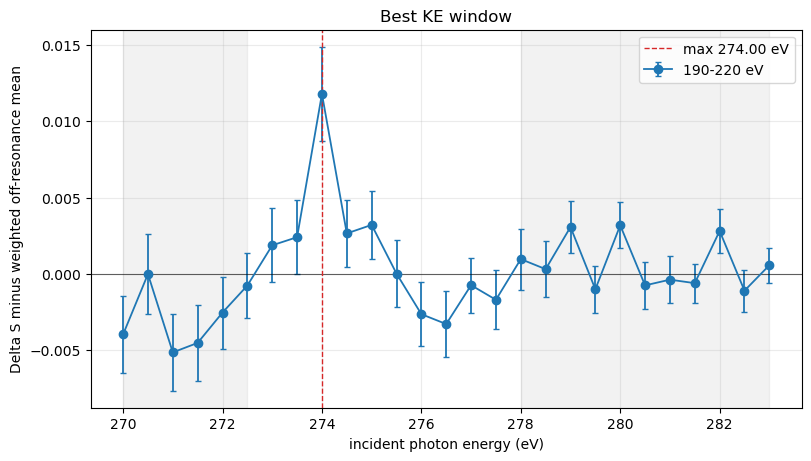

In [51]:
PEAK_KE_RANGE = (190, 220)
PEAK_ENERGY_WINDOW = (273.0, 275.0)

y = candidate_traces["delta"][PEAK_KE_RANGE]
yerr = candidate_traces["sigma"][PEAK_KE_RANGE]
br = baseline_results[PEAK_KE_RANGE]

y_zeroed = y - br["off_mean"]
y_zeroed_err = np.sqrt(yerr**2 + br["off_mean_err"]**2)

peak_mask = (
    np.isfinite(e)
    & np.isfinite(y_zeroed)
    & (e >= PEAK_ENERGY_WINDOW[0])
    & (e <= PEAK_ENERGY_WINDOW[1])
)

if np.count_nonzero(peak_mask) < 2:
    raise ValueError("Not enough points in PEAK_ENERGY_WINDOW")

e_peak = e[peak_mask]
y_peak = y_zeroed[peak_mask]
err_peak = y_zeroed_err[peak_mask]

i_max = int(np.nanargmax(y_peak))
peak_energy = e_peak[i_max]
peak_value = y_peak[i_max]
peak_sigma = err_peak[i_max]

weights = np.maximum(y_peak, 0.0)
if np.nansum(weights) > 0:
    centroid = np.nansum(e_peak * weights) / np.nansum(weights)
    rms_width = np.sqrt(np.nansum(weights * (e_peak - centroid) ** 2) / np.nansum(weights))
else:
    centroid = np.nan
    rms_width = np.nan

half_max = 0.5 * peak_value
above = y_peak >= half_max

if np.count_nonzero(above) >= 2:
    fwhm_approx = np.nanmax(e_peak[above]) - np.nanmin(e_peak[above])
else:
    fwhm_approx = np.nan

print(f"Peak estimate for KE {PEAK_KE_RANGE[0]}-{PEAK_KE_RANGE[1]} eV")
print(f"Energy search window : {PEAK_ENERGY_WINDOW[0]}-{PEAK_ENERGY_WINDOW[1]} eV")
print(f"peak maximum         : {peak_energy:.3f} eV")
print(f"peak value           : {peak_value:.6g} +/- {peak_sigma:.3g}")
print(f"positive centroid    : {centroid:.3f} eV")
print(f"RMS width            : {rms_width:.3f} eV")
print(f"approx FWHM          : {fwhm_approx:.3f} eV")

fig, ax = plt.subplots(figsize=(8, 4.5), constrained_layout=True)

ax.errorbar(
    e,
    y_zeroed,
    yerr=y_zeroed_err,
    fmt="o-",
    lw=1.3,
    capsize=2,
    label=f"{PEAK_KE_RANGE[0]}-{PEAK_KE_RANGE[1]} eV",
)

ax.axhline(0.0, color="k", lw=0.8, alpha=0.6)
ax.axvline(peak_energy, color="tab:red", lw=1.0, ls="--", label=f"max {peak_energy:.2f} eV")

for lo, hi in BASELINE_ENERGY_RANGES:
    ax.axvspan(lo, hi, color="0.8", alpha=0.25)

ax.set_xlabel("incident photon energy (eV)")
ax.set_ylabel("Delta S minus weighted off-resonance mean")
ax.set_title("Best KE window")
ax.grid(alpha=0.25)
ax.legend()

plt.show()